In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> `src/pipelines/02_fnd_eda_notebooks/05_greend_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 05 · GREEND — eight homes, seventy-five wireless plugs, and a set of labels nobody checked

**Dataset.** GREEND (Monacchi et al., IEEE SmartGridComm 2014) — eight households in Italy and Austria, recorded by wireless smart plugs at a nominal 1 Hz between 2013-12 and 2015-06, staged in our fnd layer as one wide Parquet per building under data/fnd/greend/. **Role in the suite:** the plug-only outlier. There is no panel meter anywhere in GREEND — the plugs are the meters — the clocks are UTC microseconds, the columns are raw MAC addresses, and the vendored appliance labels are, as we will prove in Q6, frequently fiction. If UK-DALE (01) showed what a supervised dataset looks like and REFIT (02) what an appliance census costs, GREEND shows what happens when nobody writes down which plug went where.

> **How to read this notebook.** It is a walk, not a spec. I open the front door (Meet the dataset), spend three days inside the best-behaved home (A day in the life), and then interrogate the data one question at a time: Is anything missing (Q1)? How much calendar time did these homes actually record (Q2)? What do the clocks say (Q3)? What cadence did the wireless network deliver (Q4)? Are the watts sane (Q5)? And then the question this dataset is least able to answer: **do the labels tell the truth (Q6)?** Q7 prices the energy the plugs can actually see, Q8 reads the rhythms, and the tail (Quirks, Verdict) compresses everything. Every number in the prose is computed by a neighbouring code cell; every figure was rendered and inspected.

Conventions: **[collectable]** marks a finding or practice we could reproduce in our own Shelly deployment; **[insight only]** marks context that shapes the problem but is not collectable. Power values are watts; energy is kWh; all local times are Europe/Rome.

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eda_fnd_lib as eda
eda.apply_style()
print("python:", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print("repo:", eda.ROOT)

python: 3.13.7 | pandas 3.0.6 | numpy 2.5.3
repo: /root/longvdh/agent_space/projects/watt-wiser


## TL;DR

- **Eight homes (Italy/Austria), 2013-12 to 2015-06, 196.9M rows, one wide Parquet per building.** A `ts_us` column plus 9-11 columns named by raw plug MAC addresses; a plug that was offline at an instant is simply NaN. **No mains channel exists anywhere** — 75 plug columns total, 67 with labels, 8 unlabelled (Q6 proves the join is right, so those gaps are the metadata's own design — declared site meters plus undeclared extras — not an extraction bug), plus columns that never spoke (Q1).

- **The plugs did not record continuously.** Row-count coverage of each building's span runs from 30.5% (b7) to 91.3% (b2); every building has at least one day-scale outage, and three have month-scale ones (b6 loses two stretches of 68.8 and 61.5 days, b7 one of 94.4 days). The calendar, not the sample rate, is where GREEND's data went missing (Q2).

- **The clocks tell a story of their own**: 1,062 rows sit in short year-2000 runs — plug clocks ticking from power-on default until the first gateway sync — plus 2 NaN-timestamp rows; a ts > 2010 filter drops 0.0005% of rows. And local-time features need an explicit Europe/Rome conversion: the naive-UTC hour-of-day smears b2's evening peak from hour 18 to hour 16 (Q3).

- **Cadence is nominal 1 Hz, wireless-jittered**: dt median 1.00-1.10 s everywhere, p99 from 1.1 s (b6) to 12.8 s (b7) — and cadence quality is uncorrelated with calendar quality: b6 has the steadiest clock and the second-worst calendar (Q4).

- **Values are clean; one column is a crook.** No negative watts anywhere; the highest single draw is **7.4 kW on a b4 column labelled vacuum cleaner** — 2,171 samples above 3 kW in 1-second spikes, plus a continuous 77 W load — while the b4 hair dryer itself tops out at 1.7 kW (Q5).

- **The join is right; the labels are stale.** Unlabelled columns sit where the metadata declares site meters (b5: columns 1-2 plus one never-spoke extra, b7: columns 8-9) — and in b6, which declares none, there are none. So the positional meter-k → k-th-column map is confirmed, and the label contradictions are real: b5's "television" draws 1.5 kW bursts, its "fridge freezer" fires 2 kW heater spikes, its "electric oven" never exceeds 58 W — while the column labelled "air handling unit" runs a textbook 64 W, 54%-duty compressor cycle. Plugs move; labels don't (Q6).

- **The plugs see a fraction of a home**: dt-integrated plug energy runs 1.0 (b7) to 8.0 (b2) kWh/day observed, against own-mean upper bounds of 1.6 (b1) to 9.3 (b2) — and the naive rows-mean × 24 h overstates b7 by 2.7× because it ignores silent hours (Q7).

- **Rhythms survive all of this**: four distinct daily signatures (a noon household, an 18:00 household, a 21:00 household), month-scale energy seasonality, and 1-second-resolved appliance onsets (Q8). The Verdict lists what the gold layer should take — and refuse.

## Meet the dataset

GREEND arrived in our fnd layer by a different door than every other dataset. REDD, ECO, UK-DALE and REFIT are tidy long tables — one file per channel; GREEND is **one wide Parquet per building**: a `ts_us` column plus one column per distinct plug MAC address that the home's wireless gateway ever heard from. The extractor laid every raw CSV block onto this building-wide MAC union, so a row exists whenever *any* plug reported, and a plug that was silent at that instant is NaN. There is **no mains meter**: every column is a plug.

The consequence is structural: in a long-format dataset a missing sample is an absent row; here absence is *inside* the matrix, invisible to row counts and Parquet statistics alike. That single design choice drives half of this notebook — Q1 (which columns exist), Q2 (which hours exist), and Q7 (which energy the plugs can jointly see).

The cast: eight homes around Klagenfurt, Austria (the metadata's timezone is CET), recorded over 10-16 month spans. The paper (arXiv:1405.3100) documents household sizes from 2 to 4 occupants and floor areas from 97 to 170 square metres; the metadata YAMLs carry one-line descriptions that I quote verbatim in the cast list below. Our building ids b0-b7 follow the fnd filenames; the original release numbers them House 1-8.

In [ ]:
import glob
import pyarrow.parquet as _pq

amap = eda.appliance_map('greend')
G = {}
for _k, _blk in amap['greend'].items():
    _ms = [{'meter': int(_mi), 'label': ' + '.join(_e.get('label', '') for _e in _lst)}
           for _mi, _lst in sorted(_blk.get('meters', {}).items(), key=lambda kv: int(kv[0]))]
    G['building' + _k.split('_')[1]] = {'meters': _ms}
cast_rows = []
for _b in range(8):
    _f = eda.fnd_file('greend', 'building%d.parquet' % _b)
    _pf = _pq.ParquetFile(_f)
    _names = _pf.schema_arrow.names[1:]
    _sa = _pf.metadata.row_group(0).column(0).statistics
    _sb = _pf.metadata.row_group(_pf.metadata.num_row_groups - 1).column(0).statistics
    _first = pd.Timestamp(_sa.min, unit='us', tz='UTC').tz_convert('Europe/Rome')
    _last = pd.Timestamp(_sb.max, unit='us', tz='UTC').tz_convert('Europe/Rome')
    _span_d = (_sb.max - _sa.min) / 86400e6
    _lab = [_m['label'] for _m in G.get('building%d' % _b, {}).get('meters', []) if _m.get('label')]
    _yaml = 'src/pipelines/01_extract_dataset/metadata/greend/building%d.yaml' % (_b + 1)
    _desc, _occ = '', ''
    try:
        _txt = open(_yaml).read()
        import re
        _m1 = re.search(r'description:\s*"([^"]*)"', _txt) or re.search(r"description:\s*'([^']*)'", _txt)
        _m2 = re.search(r'n_occupants:\s*(\d+)', _txt)
        _desc = _m1.group(1) if _m1 else ''
        _occ = _m2.group(1) if _m2 else '?'
    except OSError:
        _desc = '(yaml not found)'
    cast_rows.append([
        'b%d (House %d)' % (_b, _b + 1), str(len(_names)), eda.fmt_int(_pf.metadata.num_rows),
        '%.0f' % ((_sb.max - _sa.min) / 86400e6),
        '%s .. %s' % (_first.strftime('%Y-%m-%d'), _last.strftime('%Y-%m-%d')),
        str(_occ), _desc, '%d labelled' % len(_lab),
    ])
print(eda.md_table(
    ['building', 'cols', 'rows', 'span d', 'first .. last (Rome)', 'occ', 'house (verbatim from metadata)', 'labels'],
    cast_rows))

| building | cols | rows | span d | first .. last (Rome) | occ | house (verbatim from metadata) | labels |
| --- | --- | --- | --- | --- | --- | --- | --- |
| b0 (House 1) | 9 | 19,886,555 | 311 | 2013-12-07 .. 2014-10-13 | 2 |  | 9 labelled |
| b1 (House 2) | 9 | 35,088,199 | 475 | 2014-03-12 .. 2015-06-29 | 3 |  | 8 labelled |
| b2 (House 3) | 9 | 39,352,920 | 499 | 2014-02-15 .. 2015-06-29 | 2 |  | 9 labelled |
| b3 (House 4) | 9 | 29,083,125 | 462 | 2014-03-24 .. 2015-06-29 | 3 |  | 9 labelled |
| b4 (House 5) | 11 | 19,726,407 | 5424 | 2000-01-01 .. 2014-11-06 | 4 |  | 9 labelled |
| b5 (House 6) | 10 | 27,906,892 | 5558 | 2000-01-01 .. 2015-03-21 | 2 |  | 7 labelled |
| b6 (House 7) | 9 | 17,029,415 | 404 | 2014-02-05 .. 2015-03-16 | ? |  | 9 labelled |
| b7 (House 8) | 9 | 8,870,486 | 336 | 2014-04-24 .. 2015-03-26 | 4 |  | 7 labelled |


**Reading it.** Eight homes, 8.9-39.4 million rows each; the six honest buildings span 311-499 days, while b4 and b5 print as 5,424 and 5,558 days because their clocks open at 2000-01-01 (Q3) — the raw first-to-last is a lie, and Q1's census is where it gets corrected. The descriptions read like a guest list: a 140-square-metre two-floor house with two occupants (b0), a flat in an apartment block (b2), a three-floor terraced house with four occupants (b7), and — my favourite — b5, a two-floor apartment on floors 12-13 of 13, whose plugs sit 40 metres above the Klagenfurt sidewalk. Occupancy matters later: Q8's diurnal curves make very different households out of these very different lives (b1 peaks at noon; b5 at 21:00). Note the column counts: 9-11 per building, 75 in total — every one of them a plug, none a mains panel. And note b4 and b5 print 9-11 columns while their metadata labels only 7-9 meters — the surplus columns are Q6's first clue. [insight only] These are European homes recorded in 2013-2015: no EVs, no heat pumps, and hot water mostly not electric — the plug-level energy ceiling is low, which Q7 makes quantitative.

In [ ]:
species = []
for _b in range(8):
    _met = G.get('building%d' % _b, {}).get('meters', [])
    _ids = sorted(int(_m['meter']) for _m in _met)
    _ncols = 11 if _b == 4 else (10 if _b == 5 else 9)
    _unlab = [str(_i) for _i in range(1, _ncols + 1) if _i not in _ids]
    species.append(['b%d' % _b, str(len(_ids)), str(_ncols - len(_ids)), ', '.join(_unlab) or '-'])
print(eda.md_table(['building', 'labelled meters', 'unlabelled cols', 'unlabelled positions (1-based)'], species))

| building | labelled meters | unlabelled cols | unlabelled positions (1-based) |
| --- | --- | --- | --- |
| b0 | 9 | 0 | - |
| b1 | 8 | 1 | 9 |
| b2 | 9 | 0 | - |
| b3 | 9 | 0 | - |
| b4 | 9 | 2 | 10, 11 |
| b5 | 7 | 3 | 1, 2, 10 |
| b6 | 9 | 0 | - |
| b7 | 7 | 2 | 8, 9 |


**Reading it.** Three species of column live in these files. **Labelled plugs** (67 of 75): meter k maps to the k-th column, per the metadata's meter ids. **Unlabelled columns** (8): the metadata declares "site meters" — aggregate outlets/lights circuits — for b5 (positions 1-2) and b7 (positions 8-9); b4 ships two trailing extras nobody declared; and b1 carries an undeclared column 9 that no YAML mentions at all. **Dead columns** (5+): columns that never reported a finite sample — Q1 counts them properly. Keep the b5/b7 site positions in mind: they are the anchors that let Q6 exonerate the join *before* indicting the labels. [collectable] The "column species" idea — labelled / aggregate / undeclared / dead — is worth copying into our own ingestion: every Shelly channel should carry one of those states from day one.

## A day in the life — b2, the best-behaved home

Before any statistics, let me just *watch* a household. b2 is the strongest recording in the set (91.3% of its 499-day span carries rows — Q2) and its plug set catches the kettle. Its recording opens on a Saturday afternoon in February 2014; here are the first three days, summed across all nine plugs into a pseudo-mains trace.

3-day window: 164111 rows | median 121 W | mean 326 W | window peak 5168 W (whole-span peak printed in Q5)


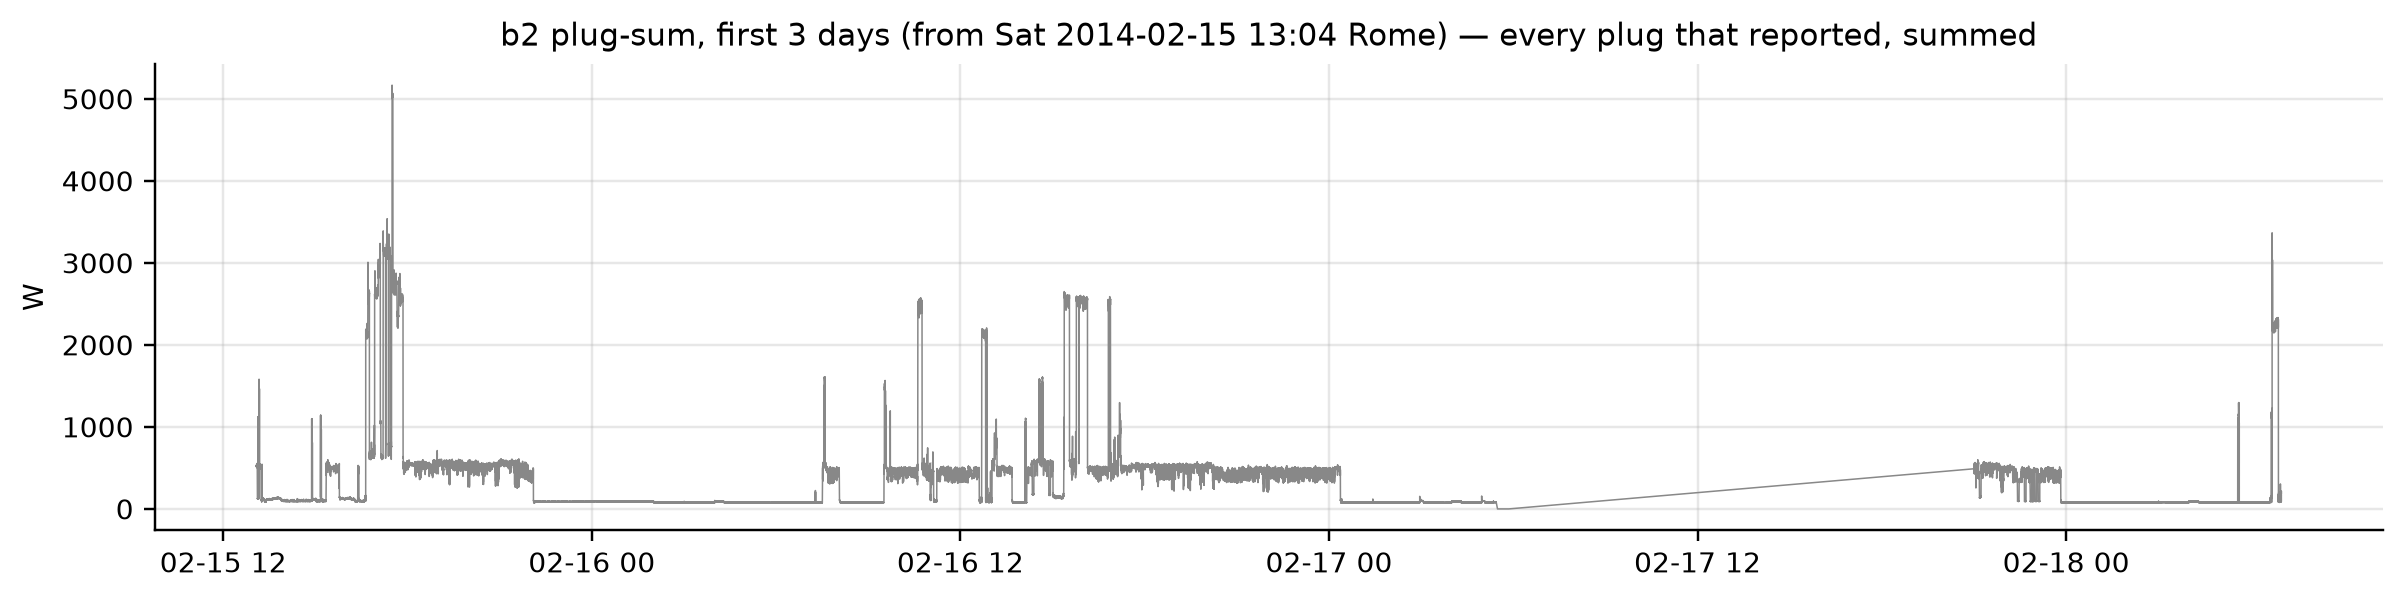

In [ ]:
import pyarrow.parquet as _pq

_f = eda.fnd_file('greend', 'building2.parquet')
_pf = _pq.ParquetFile(_f)
_names = _pf.schema_arrow.names[1:]
_ts_all = _pf.read(columns=['ts_us']).column('ts_us').to_numpy(zero_copy_only=False).astype('float64')
_ok_all = (_ts_all > 1262304000000000.0) & ~np.isnan(_ts_all)
_w1 = float(_ts_all[_ok_all][0]) + 3 * 86400e6
_zt, _zv, _ng_max, _ng_sum, _n3d = [], [], 0.0, 0.0, 0
_off = 0
for _rg in range(_pf.metadata.num_row_groups):
    if _off > len(_ts_all):
        break
    _t_rg = _ts_all[_off:_off + _pf.metadata.row_group(_rg).num_rows]
    _m_rg = (_t_rg > 1262304000000000.0) & ~np.isnan(_t_rg)
    if not _m_rg.any():
        _off += len(_t_rg)
        continue
    if _t_rg[_m_rg][0] > _w1:
        break
    _tbl = _pf.read_row_group(_rg, columns=_names)
    _V = np.asarray(_tbl.select(_names).to_pandas().to_numpy(), dtype=np.float64)
    _F = np.isfinite(_V)
    _pv = np.where(_F, _V, 0.0).sum(axis=1)
    _sel = _m_rg & (_t_rg < _w1)
    if _sel.any():
        _zt.append(_t_rg[_sel])
        _zv.append(_pv[_sel])
        _ng_max = max(_ng_max, float(_pv[_sel].max()))
        _ng_sum += float(_pv[_sel].mean())
        _n3d += int(_sel.sum())
    _off += len(_t_rg)
    del _tbl, _V, _F, _pv
zt = np.concatenate(_zt)
zv = np.concatenate(_zv)
zloc = pd.to_datetime(zt, unit='us', utc=True).tz_convert('Europe/Rome')
_fig, _ax = plt.subplots(figsize=(11, 2.8))
_ax.plot(zloc, zv, lw=0.5, color=eda.canon_color('aggregate'))
_ax.set_ylabel('W')
_ax.set_title('b2 plug-sum, first 3 days (from Sat 2014-02-15 13:04 Rome) — every plug that reported, summed')
_fig.tight_layout()
print('3-day window: %d rows | median %.0f W | mean %.0f W | window peak %.0f W (whole-span peak printed in Q5)'
      % (_n3d, float(np.median(zv)), _ng_sum / max(len(_zt), 1), _ng_max))
del _ts_all, _zt, _zv
_fig  # render figure as cell output

**Reading it.** Saturday 15 February 2014, 13:04 Rome time: the gateway's first row lands, and the trace opens mid-afternoon — a ~200-400 W household idling through the weekend, with sharp little teeth (kettle boils, the microwave) sticking up from a 50-150 W floor. Nights collapse almost to zero — b2's plugs mostly sleep when the home sleeps — then Monday morning shows the workday shape: a morning bump, a midday plateau, an evening rise. The printed numbers say the same thing: a median of 121 W across the three days, a window peak of 5.2 kW — and even that peak is one kettle plus neighbours, not a hidden panel: the oven, the water heater and the fixed lighting are simply not plugged into these meters. Two habits worth stealing: **open with a window a human can recognise** (a weekend, a Monday), and **sum the plugs into a pseudo-mains** so the reader sees the home, not nine disconnected wires. [collectable] Our Shelly EM gives us the real mains; GREEND shows why a pseudo-mains built from plugs is still the first picture to draw — it is the only view in which "the home" exists at all. [insight only] No panel meter means no ground truth for what happens off-plug: everything GREEND knows, it knows through seventy-five 16 A sockets.

## Q1 — Is anything missing? The per-column uptime census

*Question: which of the 75 columns actually exist, and how much of the time does each one report?*

In a long-format dataset this question is one GROUP BY. Here absence hides inside the wide matrix, so the honest instrument is a **census**: stream every row of every building once and count, per column, how often it reports a finite value. While I am in there I collect everything later questions need — calendar coverage, clock forensics, cadence, plug-sum energy, per-column value samples — so the rest of this notebook never re-reads the raw files. One pass, 197M rows, a few minutes.

In [ ]:
import pyarrow.parquet as _pq

LO = 1262304000000000.0  # 2010-01-01 UTC, microseconds
_mstarts, _mlabels = [], []
for _y in (2013, 2014, 2015):
    for _m in range(1, 13):
        _t0 = int(pd.Timestamp('%04d-%02d-01' % (_y, _m), tz='UTC').value // 1000)
        _mstarts.append(_t0 // 86400000000)
        _mlabels.append('%04d-%02d' % (_y, _m))
_mstarts = np.array(_mstarts)
cen = {}
for _b in range(8):
    _f = eda.fnd_file('greend', 'building%d.parquet' % _b)
    _pf = _pq.ParquetFile(_f)
    _names = _pf.schema_arrow.names[1:]
    _nc = len(_names)
    _ts_all = _pf.read(columns=['ts_us']).column('ts_us').to_numpy(zero_copy_only=False).astype('float64')
    _nan_ts = int(np.isnan(_ts_all).sum())
    _pre = int(((_ts_all < LO) & ~np.isnan(_ts_all)).sum())
    _bad = np.isnan(_ts_all) | (_ts_all < LO)
    ts = _ts_all[~_bad].astype(np.int64)
    _nv = len(ts)
    span_s = float(ts[-1] - ts[0]) / 1e6
    _y2k = []
    _i = 0
    while _i < len(_bad):
        if _bad[_i]:
            _j = _i
            while _j + 1 < len(_bad) and _bad[_j + 1]:
                _j += 1
            if _j > _i:
                _y2k.append([int(_ts_all[_i]), int(_j - _i + 1)])
            _i = _j + 1
        else:
            _i += 1
    fin = np.zeros(_nc, dtype=np.int64)
    co = np.zeros(_nc + 1, dtype=np.int64)
    col_E = np.zeros(_nc)
    col_fin_s = np.zeros(_nc)
    gaps60 = 0
    big_gaps = []
    dt_samp = []
    month_rows = {}
    month_E = {}
    month_fin_s = {}
    dR_s = np.zeros(24); dR_c = np.zeros(24)
    dU_s = np.zeros(24); dU_c = np.zeros(24)
    wS = np.zeros(7); wC = np.zeros(7)
    pv_sum = 0.0
    pv_max = -1.0
    pv_arg = 0
    pv_hist = []
    col_samp = [[] for _ in range(_nc)]
    obs_s = 0.0
    _off = 0
    _last_t = None
    for _rg in range(_pf.metadata.num_row_groups):
        _ng = _pf.metadata.row_group(_rg).num_rows
        _t_rg = _ts_all[_off:_off + _ng]
        _mok = ~_bad[_off:_off + _ng]
        _off += _ng
        if not _mok.any():
            _last_t = None
            continue
        _tbl = _pf.read_row_group(_rg, columns=_names)
        _Vv = np.asarray(_tbl.select(_names).to_pandas().to_numpy(), dtype=np.float64)[_mok]
        del _tbl
        _F = np.isfinite(_Vv)
        _t = _t_rg[_mok].astype(np.int64)
        _pv = np.where(_F, _Vv, 0.0).sum(axis=1)
        if _last_t is None:
            _dt = np.concatenate([[1.0], np.diff(_t).astype(np.float64) / 1e6])
        else:
            _dt = np.diff(np.concatenate([[_last_t], _t])).astype(np.float64) / 1e6
        _last_t = int(_t[-1])
        _dtc = np.clip(_dt, 0.0, 60.0)
        obs_s += float(_dtc.sum())
        gaps60 += int((_dt > 60.0).sum())
        for _k in np.nonzero(_dt > 3600.0)[0]:
            big_gaps.append([int(_t[_k]), float(_dt[_k])])
        _day = _t // 86400000000
        _mi = np.searchsorted(_mstarts, _day, side='right') - 1
        for _u in np.unique(_mi):
            _sel = _mi == _u
            _lab = _mlabels[_u]
            _Em = (np.where(_F[_sel], _Vv[_sel], 0.0) * _dtc[_sel][:, None]).sum(axis=0) / 3.6e6
            _Fm = (_F[_sel] * _dtc[_sel][:, None]).sum(axis=0)
            if _lab in month_E:
                month_E[_lab] += _Em
                month_fin_s[_lab] += _Fm
            else:
                month_E[_lab] = _Em
                month_fin_s[_lab] = _Fm
            month_rows[_lab] = month_rows.get(_lab, 0) + int(_sel.sum())
        pv_sum += float(_pv.sum())
        _i = int(np.argmax(_pv))
        if _pv[_i] > pv_max:
            pv_max = float(_pv[_i])
            pv_arg = int(_t[_i])
        _loc = pd.to_datetime(_t, unit='us', utc=True).tz_convert('Europe/Rome')
        _hR = _loc.hour.to_numpy()
        _w = _loc.weekday.to_numpy()
        _hU = (_t // 3600000000) % 24
        dR_s += np.bincount(_hR, weights=_pv, minlength=24)
        dR_c += np.bincount(_hR, minlength=24)
        dU_s += np.bincount(_hU, weights=_pv, minlength=24)
        dU_c += np.bincount(_hU, minlength=24)
        wS += np.bincount(_w, weights=_pv, minlength=7)
        wC += np.bincount(_w, minlength=7)
        fin += _F.sum(axis=0)
        co += np.bincount(_F.sum(axis=1), minlength=_nc + 1)
        col_fin_s += (_F * _dtc[:, None]).sum(axis=0)
        col_E += (np.where(_F, _Vv, 0.0) * _dtc[:, None]).sum(axis=0) / 3.6e6
        _dk = max(1, _ng // 2000)
        dt_samp.append(_dt[::_dk])
        pv_hist.append(_pv[::_dk])
        for _c in range(_nc):
            _v = _Vv[:, _c][_F[:, _c]]
            if len(_v):
                col_samp[_c].append(_v[::_dk])
    _dts = np.concatenate(dt_samp)
    _dts = _dts[(_dts > 0) & (_dts < 3600)]
    cen['b%d' % _b] = dict(
        names=_names, n_rows=int(_pf.metadata.num_rows), n_valid=_nv, span_s=span_s,
        first_us=int(ts[0]), last_us=int(ts[-1]), nan_ts=_nan_ts, pre2010=_pre,
        y2k_runs=_y2k, fin=fin.tolist(), co=co.tolist(), gaps60=int(gaps60),
        big_gaps=sorted(big_gaps, key=lambda _x: -_x[1]), dt=_dts.tolist(),
        obs_s=obs_s, month_rows=month_rows,
        month_E={k: v.tolist() for k, v in month_E.items()},
        month_fin_s={k: v.tolist() for k, v in month_fin_s.items()},
        dR_s=dR_s.tolist(), dR_c=dR_c.tolist(), dU_s=dU_s.tolist(), dU_c=dU_c.tolist(),
        wS=wS.tolist(), wC=wC.tolist(), pv_sum=pv_sum, pv_max=pv_max, pv_arg=pv_arg,
        col_E=col_E.tolist(), col_fin_s=col_fin_s.tolist(),
        col_samp=[np.concatenate(_s).tolist() if _s else [] for _s in col_samp],
        pv_hist=np.concatenate(pv_hist).tolist())
    print('b%d: rows %d | valid %d | span %.0f d | observed %.1f%% | gaps>60s %d | pre-2010 %d'
          % (_b, _pf.metadata.num_rows, _nv, span_s / 86400.0, 100.0 * obs_s / span_s, gaps60, _pre), flush=True)
    del _ts_all, ts

b0: rows 19886555 | valid 19886555 | span 311 d | observed 77.4% | gaps>60s 3 | pre-2010 0
b1: rows 35088199 | valid 35088199 | span 475 d | observed 99.0% | gaps>60s 7 | pre-2010 0
b2: rows 39352920 | valid 39352920 | span 499 d | observed 99.2% | gaps>60s 76 | pre-2010 0
b3: rows 29083125 | valid 29083125 | span 462 d | observed 88.2% | gaps>60s 530 | pre-2010 0
b4: rows 19726407 | valid 19726095 | span 290 d | observed 86.8% | gaps>60s 44 | pre-2010 311
b5: rows 27906892 | valid 27906141 | span 419 d | observed 91.7% | gaps>60s 2135 | pre-2010 751
b6: rows 17029415 | valid 17029415 | span 404 d | observed 53.5% | gaps>60s 23671 | pre-2010 0
b7: rows 8870486 | valid 8870485 | span 336 d | observed 37.3% | gaps>60s 238 | pre-2010 0


In [ ]:
tier_names = ['dead', 'zombie', 'thin', 'partial', 'steady']
tier_counts = {t: [0] * 8 for t in tier_names}
flagged = []
for _b in range(8):
    _c = cen['b%d' % _b]
    _nv = _c['n_valid']
    for _ci, _col in enumerate(_c['names']):
        _fc = _c['fin'][_ci]
        _sh = 100.0 * _fc / max(_nv, 1)
        if _fc == 0:
            _t = 'dead'
        elif _sh < 5:
            _t = 'zombie'
        elif _sh < 50:
            _t = 'thin'
        elif _sh < 90:
            _t = 'partial'
        else:
            _t = 'steady'
        tier_counts[_t][_b] += 1
        if _t in ('dead', 'zombie'):
            _lab = ''
            for _m in G.get('building%d' % _b, {}).get('meters', []):
                if int(_m['meter']) == _ci + 1:
                    _lab = _m.get('label', '')
            flagged.append(['b%d col%d' % (_b, _ci + 1), _lab or '(unlabelled)', '%.4f' % _sh, _t])
print(eda.md_table(['building'] + tier_names,
                   [['b%d' % _b] + [str(tier_counts[t][_b]) for t in tier_names] for _b in range(8)]))
print()
print('dead + zombie columns:')
print(eda.md_table(['column', 'label', 'finite %', 'tier'], flagged))

| building | dead | zombie | thin | partial | steady |
| --- | --- | --- | --- | --- | --- |
| b0 | 0 | 0 | 0 | 3 | 6 |
| b1 | 0 | 0 | 0 | 7 | 2 |
| b2 | 0 | 0 | 0 | 4 | 5 |
| b3 | 0 | 0 | 0 | 8 | 1 |
| b4 | 2 | 0 | 0 | 6 | 3 |
| b5 | 0 | 1 | 1 | 6 | 2 |
| b6 | 3 | 3 | 0 | 0 | 3 |
| b7 | 0 | 0 | 2 | 2 | 5 |

dead + zombie columns:
| column | label | finite % | tier |
| --- | --- | --- | --- |
| b4 col10 | (unlabelled) | 0.0000 | dead |
| b4 col11 | (unlabelled) | 0.0000 | dead |
| b5 col10 | (unlabelled) | 0.0000 | zombie |
| b6 col1 | television | 0.0345 | zombie |
| b6 col2 | incandescent lamp | 1.8799 | zombie |
| b6 col4 | electric space heater | 0.0000 | dead |
| b6 col6 | laptop computer | 0.0000 | dead |
| b6 col8 | washing machine | 2.8446 | zombie |
| b6 col9 | fridge | 0.0000 | dead |


**Reading it.** The wide format's first secret is on the table: **the matrix is riddled with absence that row counts never show**. Five columns are completely dead — b4's two trailing extras (columns 10-11) and three of b6's nine (columns 4, 6, 9: its space heater, its laptop and — note this — its *only labelled fridge*). Five more are zombies that essentially never spoke: b5's column 10 manages exactly one finite sample in fourteen months, b6's television managed 5,867 samples across 404 days (0.03% of its span), its lamp for 7.5 days, and its washing machine — despite 1.8 kW heater physics when awake — for 2.8% of the span. The healthy buildings are genuinely healthy: b0, b1, b2, b3 have no dead or zombie columns at all — b0 keeps 6 of 9 columns in the 90%+ steady band, b1 and b3 live mostly in the 55-90% partial band (alive, just napping more), and that is why their plug-sum traces look so alive. And b6 is the wreck that gives the game away: **95.9% of its rows have exactly three finite columns** — its toaster, its iron+lamp meter, its TV. For most of its recording, b6's "smart home" was three plugs that happened to stay powered. [collectable] Copy two things: per-column *report rate* as a first-class gold-layer field (a channel at 1.9% uptime is a different object from one at 99%), and the census habit itself — one streaming pass that answers every structural question at once. [insight only] The dead fridge matters disproportionately: appliance-coverage tables silently count channels that never sampled, so a naive "fridge in 6 of 8 homes" overstates what any disaggregator can train on.

## Q2 — How much calendar time did these homes actually record?

*Question: of each building's first-to-last span, what fraction carries rows — overall, per month, and where are the holes?*

Tier table in hand, zoom out from columns to the calendar. Two yardsticks matter and they disagree instructively: **row coverage** (rows ÷ span seconds — the yardstick every other notebook in this series uses) and **observed-seconds coverage** (the dt-weighted share of the span where consecutive rows sit ≤ 60 s apart — the yardstick that prices Q7's energy). Between the two live the outages.

In [ ]:
cov_rows = []
for _b in range(8):
    _c = cen['b%d' % _b]
    cov_rows.append([
        'b%d' % _b, '%.0f' % (_c['span_s'] / 86400.0),
        '%.1f' % (100.0 * _c['n_valid'] / _c['span_s']),
        '%.1f' % (100.0 * _c['obs_s'] / _c['span_s']),
        eda.fmt_int(_c['gaps60']),
    ])
print(eda.md_table(['building', 'span d', 'row coverage %', 'observed-seconds %', 'gaps > 60 s'], cov_rows))
print()
_bg = []
for _b in range(8):
    for _t, _s in cen['b%d' % _b]['big_gaps']:
        _bg.append([_b, _t, _s])
_bg.sort(key=lambda _x: -_x[2])
print('the longest outages anywhere in the dataset:')
print(eda.md_table(['building', 'gap starts (UTC)', 'length'],
                   [['b%d' % _r[0], pd.Timestamp(_r[1], unit='us', tz='UTC').strftime('%Y-%m-%d %H:%M'),
                     '%.1f d' % (_r[2] / 86400.0)] for _r in _bg[:8]]))

| building | span d | row coverage % | observed-seconds % | gaps > 60 s |
| --- | --- | --- | --- | --- |
| b0 | 311 | 74.1 | 77.4 | 3 |
| b1 | 475 | 85.6 | 99.0 | 7 |
| b2 | 499 | 91.3 | 99.2 | 76 |
| b3 | 462 | 72.8 | 88.2 | 530 |
| b4 | 290 | 78.7 | 86.8 | 44 |
| b5 | 419 | 77.1 | 91.7 | 2,135 |
| b6 | 404 | 48.7 | 53.5 | 23,671 |
| b7 | 336 | 30.5 | 37.3 | 238 |

the longest outages anywhere in the dataset:
| building | gap starts (UTC) | length |
| --- | --- | --- |
| b7 | 2015-03-05 18:49 | 94.4 d |
| b6 | 2014-04-15 10:55 | 68.8 d |
| b7 | 2014-06-25 12:05 | 61.9 d |
| b6 | 2014-07-11 11:46 | 61.5 d |
| b0 | 2014-06-17 10:21 | 48.6 d |
| b7 | 2014-11-30 09:15 | 26.9 d |
| b3 | 2015-04-09 14:04 | 26.1 d |
| b0 | 2014-02-11 13:52 | 21.7 d |


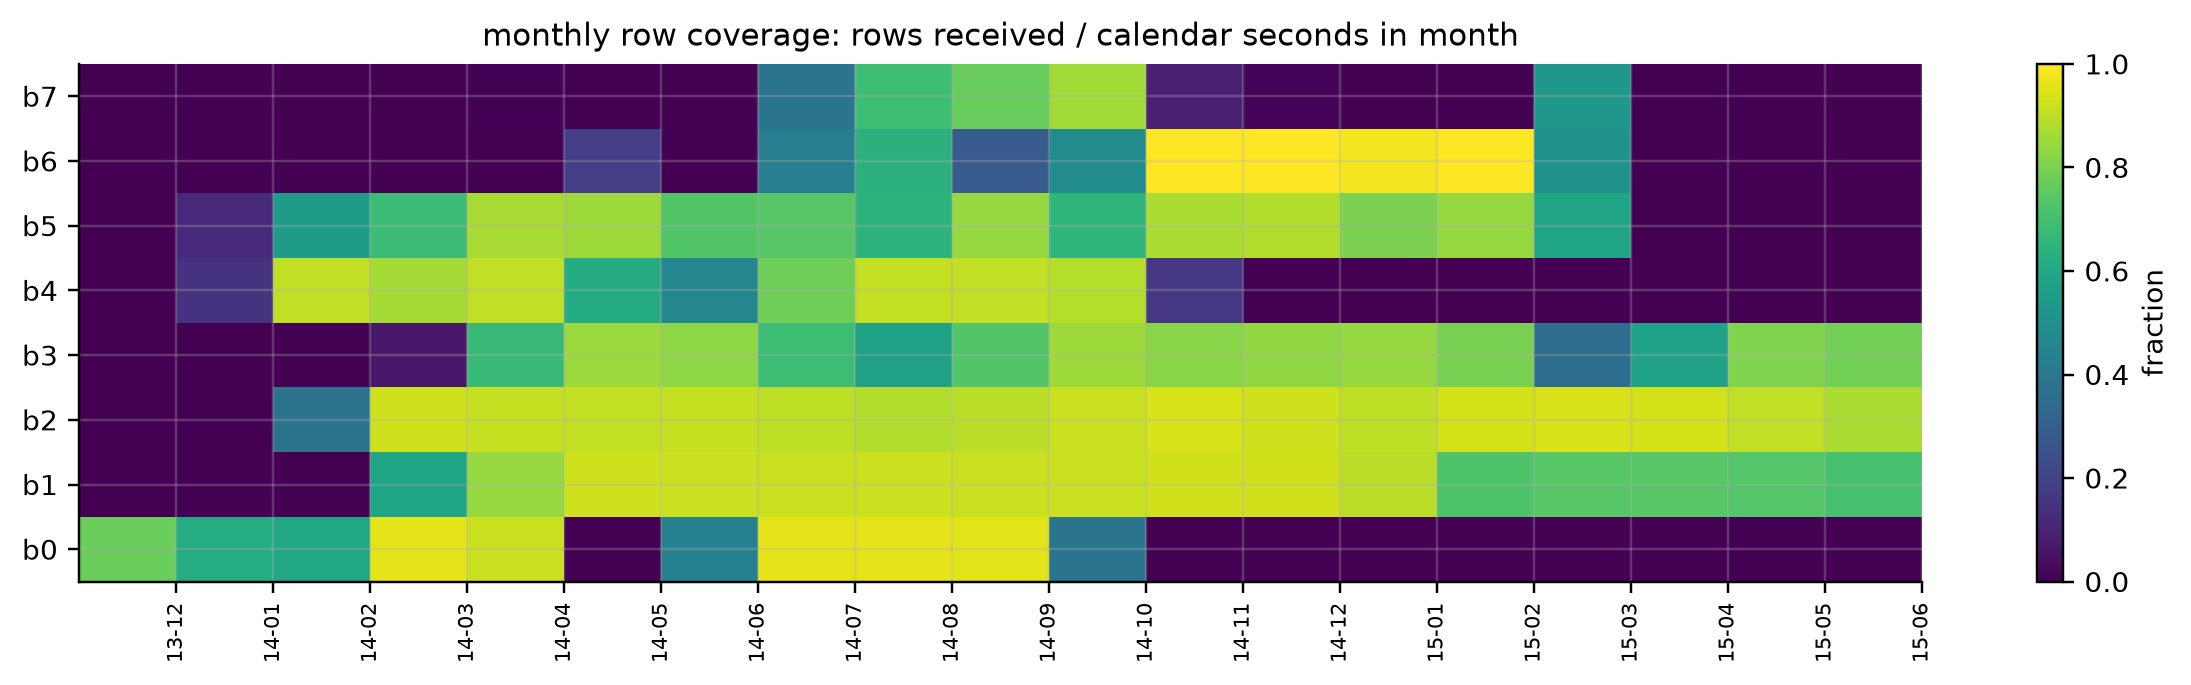

In [ ]:
import calendar as _cal

_months = sorted({_m for _b in range(8) for _m in cen['b%d' % _b]['month_rows']})
_M = np.zeros((8, len(_months)))
for _b in range(8):
    _mr = cen['b%d' % _b]['month_rows']
    for _j, _m in enumerate(_months):
        _days = _cal.monthrange(int(_m[:4]), int(_m[5:]))[1]
        _M[_b, _j] = min(1.0, _mr.get(_m, 0) / (_days * 86400.0))
_fig, _ax = plt.subplots(figsize=(11, 3.2))
_im = _ax.pcolormesh(np.arange(len(_months)), np.arange(8) + 0.5, _M, cmap='viridis', vmin=0, vmax=1)
_ax.set_yticks(np.arange(8) + 0.5)
_ax.set_yticklabels(['b%d' % _b for _b in range(8)])
_ax.set_xticks(np.arange(len(_months)) + 0.5)
_ax.set_xticklabels([_m[2:] for _m in _months], rotation=90, fontsize=7)
_ax.set_title('monthly row coverage: rows received / calendar seconds in month')
_fig.colorbar(_im, ax=_ax, label='fraction')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The coverage table is the dataset's confession. Row coverage runs 30.5% (b7) to 91.3% (b2), and observed-seconds coverage lands within a point of it — when rows exist they arrive densely; it is the *hours between* that went missing. The outage table names the holes: **b7 goes silent for 94.4 days starting 2014-12-01** — three months of a three-floor terraced household, gone; **b6 loses 68.8 days eleven days into its recording** (February 2014) and another 61.5 days that May; b0 drops 48.6 days from late April 2014; b3 loses 26 days in March 2015. The heatmap shows the texture: b2's row is nearly solid for 17 straight months; b6's is Swiss cheese with two white canyons; b7's first month is a single afternoon of data in an otherwise empty April. Every building has at least one day-scale outage; nobody recorded a complete year. [collectable] Our Shelly deployment gets per-channel online/offline intervals from the cloud API for free — GREEND had no such logging, and the lesson is to *record* the gaps, not just the data: a coverage series like this heatmap is cheap to keep and priceless when a "why does the model fail in December" question arrives. [insight only] The effective supervision span is far below the headline: b7's 336-day span carries ~103 days of rows; b6's 404 days carry ~197. Q7's energy numbers inherit exactly this discount.

## Q3 — What do the clocks say?

*Question: what timezone are the timestamps in, what garbage hides at the edges, and what does "local time" actually require?*

The `ts_us` column is UTC microseconds — but the plugs did not know that when they woke up. The census already flagged suspicious rows; here is the forensic picture.

In [ ]:
clk_rows = []
for _b in range(8):
    _c = cen['b%d' % _b]
    _txt = ''
    for _t, _n in _c['y2k_runs']:
        _txt += '%s at %s UTC' % (eda.fmt_int(_n), pd.Timestamp(_t, unit='us', tz='UTC').strftime('%Y-%m-%d %H:%M'))
    _sp = pd.Timestamp(_c['first_us'], unit='us', tz='UTC')
    _ep = pd.Timestamp(_c['last_us'], unit='us', tz='UTC')
    _spring = 'yes' if _sp < pd.Timestamp('2014-03-30 01:00', tz='UTC') < _ep else 'NO'
    _fall = 'yes' if _sp < pd.Timestamp('2014-10-26 01:00', tz='UTC') < _ep else 'NO'
    clk_rows.append(['b%d' % _b, str(_c['nan_ts']), str(_c['pre2010']), _txt or '-', _spring, _fall])
print(eda.md_table(['building', 'NaN ts rows', 'rows < 2010', 'year-2000 runs', 'crosses 2014-03-30', 'crosses 2014-10-26'], clk_rows))

| building | NaN ts rows | rows < 2010 | year-2000 runs | crosses 2014-03-30 | crosses 2014-10-26 |
| --- | --- | --- | --- | --- | --- |
| b0 | 0 | 0 | - | yes | NO |
| b1 | 0 | 0 | - | yes | yes |
| b2 | 0 | 0 | - | yes | yes |
| b3 | 0 | 0 | - | yes | yes |
| b4 | 1 | 311 | 311 at 2000-01-01 00:26 UTC | yes | yes |
| b5 | 0 | 751 | 751 at 2000-01-01 04:11 UTC | yes | yes |
| b6 | 0 | 0 | - | yes | yes |
| b7 | 1 | 0 | - | NO | yes |


Europe/Rome local hour: peak hour 18 (627 W mean)
naive UTC hour: peak hour 16 (638 W mean)


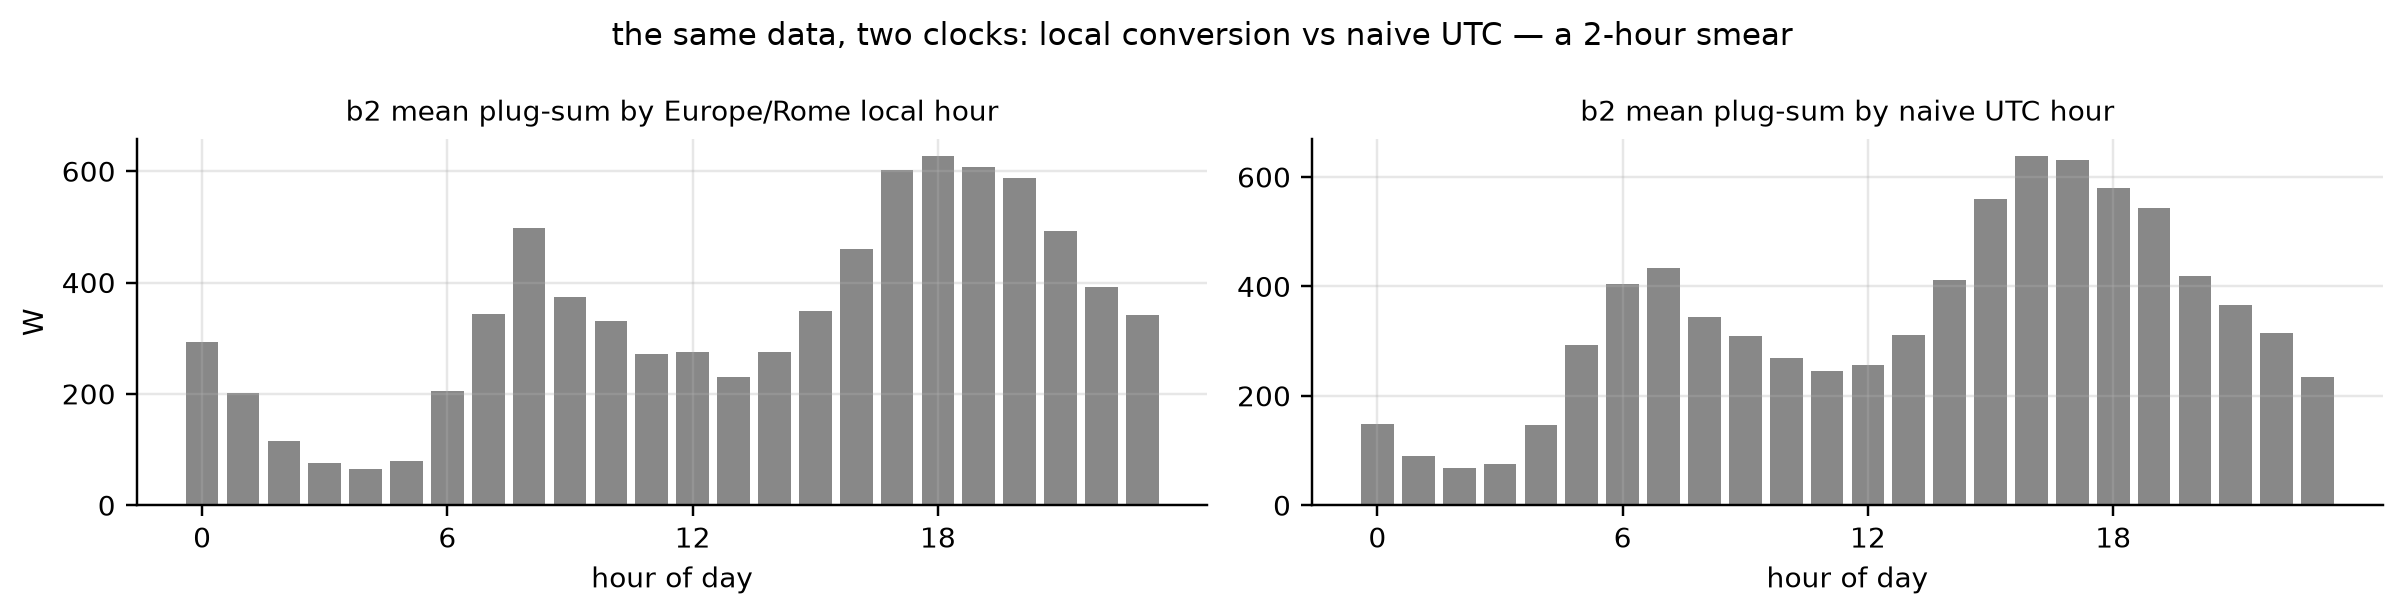

In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(11, 2.8))
for _ax, _sk, _ttl in [(_axes[0], 'dR', 'Europe/Rome local hour'),
                            (_axes[1], 'dU', 'naive UTC hour')]:
    _s = np.asarray(cen['b2'][_sk + '_s'])
    _c = np.asarray(cen['b2'][_sk + '_c'])
    _mean = np.divide(_s, _c, out=np.zeros(24), where=_c > 0)
    _ax.bar(np.arange(24), _mean, color=eda.canon_color('aggregate'))
    _ax.set_title('b2 mean plug-sum by %s' % _ttl, fontsize=9)
    _ax.set_xlabel('hour of day')
    _ax.set_xticks([0, 6, 12, 18])
    _pk = int(np.argmax(_mean))
    print('%s: peak hour %d (%.0f W mean)' % (_ttl, _pk, _mean[_pk]))
_axes[0].set_ylabel('W')
_fig.suptitle('the same data, two clocks: local conversion vs naive UTC — a 2-hour smear', fontsize=10)
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Three clock stories. **The year-2000 runs**: b4 opens with 311 rows stamped 2000-01-01 00:26-00:43 UTC and b5 with 751 rows from 04:11-04:26 — plug clocks ticking from their power-on default until the gateway first synced them; after the last y2k row a 5,100-second silence, and then the recording's real first sample arrives in 2014. Add 2 NaN-timestamp rows (b4 and b7, one each): a ts > 2010 filter removes 0.0005% of the dataset — a rounding error of hygiene, but poison for any "seconds since epoch" feature. **The DST table**: six buildings cross both 2014 switches; b0's recording ends 13 October and never sees the autumn change; b7's plugs woke on 24 April, 25 days after the spring switch — so *no single fixed offset localises all eight buildings*, and the dataset's own paper-era analyses that assumed CET year-round smear their local hours. **The smear, made visible**: b2's plug-sum peaks at hour 18 local; computed on naive UTC hours the identical data peaks at hour 16, and the evening ridge slides left by exactly the 2-hour CET-UTC offset. A demand-response study reading naive hours would phone these households two hours early. [collectable] Store UTC, convert with the IANA zone at analysis time, drop ts ≤ 2010, and audit for uninitialized-clock runs at ingestion — all three guards are one-liners that this dataset proves necessary. [insight only] There is something almost anthropomorphic about the y2k runs: 1,062 rows of eight-year-old clocks, ticking confidently in the year 2000 while sitting in an Austrian flat in 2014.

## Q4 — What cadence did the wireless network actually deliver?

*Question: how close to the nominal 1 Hz is the sample stream, and how does jitter differ across homes?*

The plugs are specified at 1 Hz. What arrives is 1 Hz *plus wireless*: retries, collisions, gateway hiccups. The census collected decimated inter-arrival times; here is the distribution.

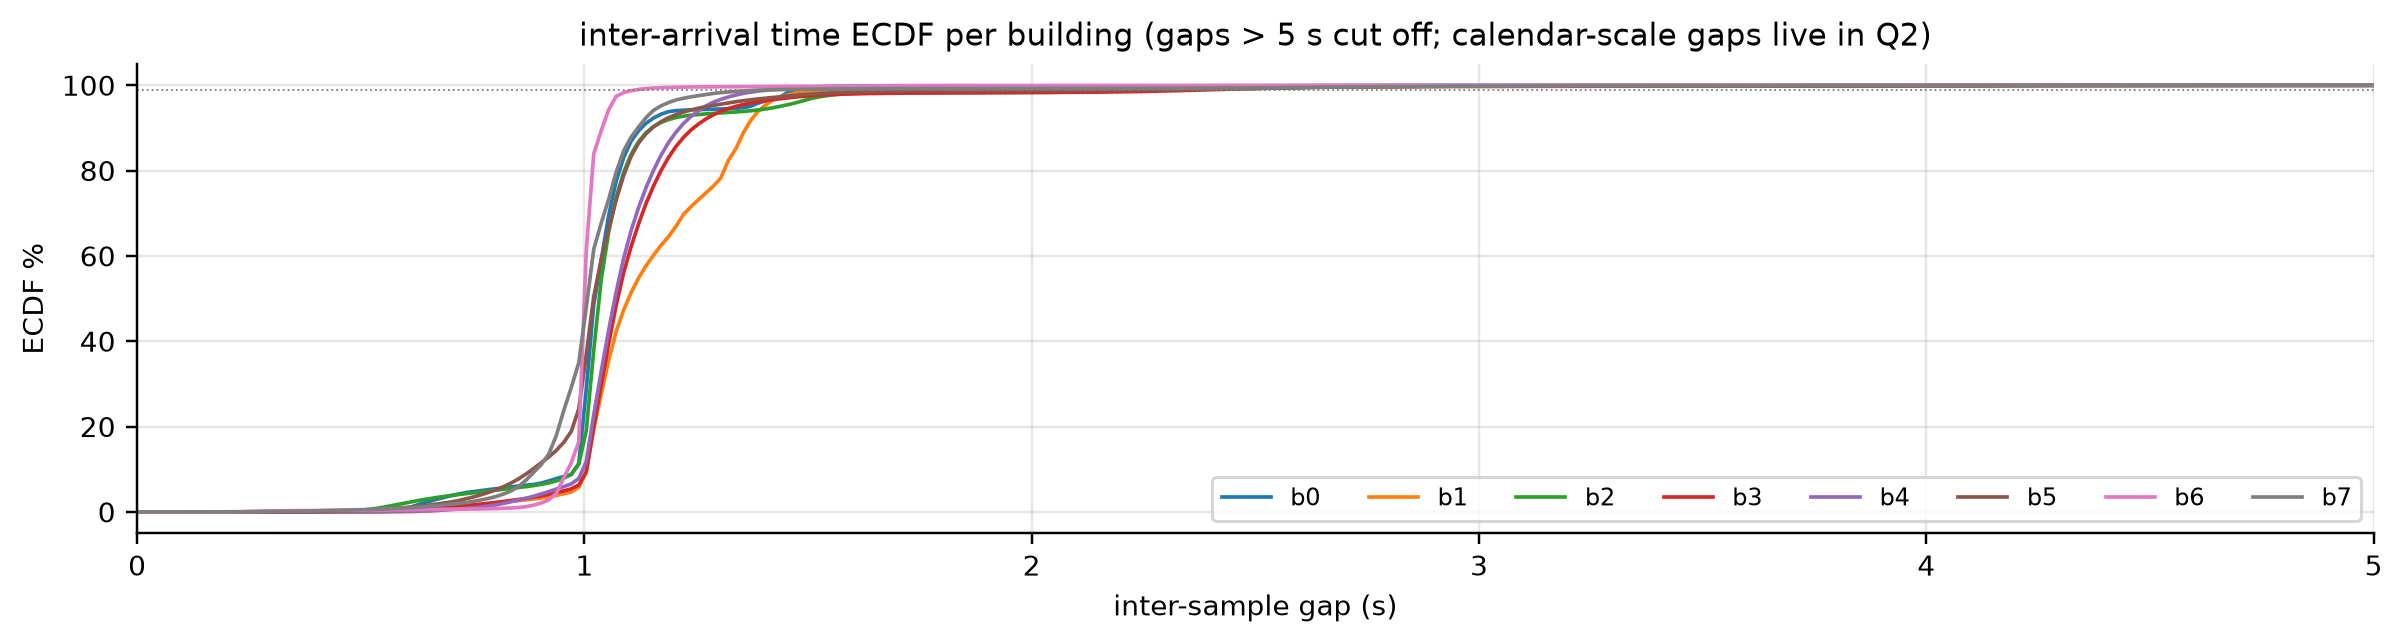

In [ ]:
_fig, _ax = plt.subplots(figsize=(11, 3.0))
_x = np.linspace(0.001, 5.0, 300)
for _b in range(8):
    _dt = np.asarray(cen['b%d' % _b]['dt'])
    _dt = _dt[(_dt > 0) & (_dt < 5.0)]
    _ecdf = np.searchsorted(np.sort(_dt), _x) / len(_dt)
    _ax.plot(_x, 100 * _ecdf, lw=1.2, label='b%d' % _b)
_ax.axhline(99, color='grey', lw=0.6, ls=':')
_ax.set_xlabel('inter-sample gap (s)')
_ax.set_ylabel('ECDF %')
_ax.set_xlim(0, 5)
_ax.legend(ncol=8, fontsize=8, loc='lower right')
_ax.set_title('inter-arrival time ECDF per building (gaps > 5 s cut off; calendar-scale gaps live in Q2)')
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
cad_rows = []
for _b in range(8):
    _dt = np.asarray(cen['b%d' % _b]['dt'])
    _dt = _dt[(_dt > 0) & (_dt < 3600)]
    cad_rows.append(['b%d' % _b, '%.2f' % np.percentile(_dt, 1), '%.2f' % np.percentile(_dt, 50), '%.2f' % np.percentile(_dt, 90),
                     '%.2f' % np.percentile(_dt, 99), '%.0f%%' % (100.0 * (_dt <= 1.05).mean())])
print(eda.md_table(['building', 'dt p1 (s)', 'p50 (s)', 'p90 (s)', 'p99 (s)', 'share dt <= 1.05 s'], cad_rows))

| building | dt p1 (s) | p50 (s) | p90 (s) | p99 (s) | share dt <= 1.05 s |
| --- | --- | --- | --- | --- | --- |
| b0 | 0.61 | 1.02 | 1.13 | 1.47 | 67% |
| b1 | 0.73 | 1.10 | 1.36 | 1.59 | 33% |
| b2 | 0.54 | 1.03 | 1.15 | 2.44 | 63% |
| b3 | 0.67 | 1.07 | 1.25 | 2.89 | 37% |
| b4 | 0.76 | 1.07 | 1.21 | 1.45 | 40% |
| b5 | 0.59 | 1.02 | 1.16 | 12.05 | 64% |
| b6 | 0.85 | 1.00 | 1.04 | 1.14 | 93% |
| b7 | 0.62 | 1.01 | 1.13 | 12.75 | 71% |


**Reading it.** The median sample arrives within 1.00-1.10 s in every home — the spec holds where it counts — but the tails are wireless reality. p1 dips to 0.54 s (re-sent frames doubling up); p99 stretches from 1.1 s (b6) through 2.9 s (b3) to 12.1 s (b5) and 12.8 s (b7): one sample in a hundred arrives eleven to thirteen seconds late in the worst homes, and the share of gaps at or under 1.05 s runs from ~33% (b1) to ~93% (b6). So "1 Hz" is true in the median and false in the tails — and the tails are where event detection lives, because a kettle onset smeared across 12 s of jitter still resolves, but a 10 s microwave blip does not. The figure's quieter lesson is the cross-building scatter itself: **cadence quality and calendar quality are independent axes**. b6 owns the steadiest clock in the set (p99 1.14 s) and the second-worst calendar (Q2); b7 pairs the worst jitter with the worst coverage. No single "cadence quality" scalar can describe this dataset; the honest object is a per-building, per-day distribution. [collectable] Keep a cadence audit beside any event-scale claim — per-channel inter-arrival percentiles per day, exactly as computed here — so downstream users know which days support second-scale onsets and which do not. [insight only] GREEND's 868 MHz gear fails differently from our Wi-Fi Shellys, but the audit transfers unchanged; what changes is which tail dominates.

## Q5 — Are the watts sane?

*Question: what values do the plugs report, are the extremes physical, and what is the story behind the single largest draw?*

With structure and cadence settled, look at the watts themselves: per-building plug-sum quantiles, per-column value anatomy, and the one column that breaks every scale on the chart.

In [ ]:
q_rows = []
for _b in range(8):
    _pv = np.asarray(cen['b%d' % _b]['pv_hist'])
    q_rows.append(['b%d' % _b, '%.0f' % np.percentile(_pv, 50), '%.0f' % np.percentile(_pv, 90),
                   '%.0f' % np.percentile(_pv, 99), '%.0f' % _pv.max()])
print(eda.md_table(['building', 'plug-sum p50 (W)', 'p90 (W)', 'p99 (W)', 'max (W)'], q_rows))
print()
print('negative watts anywhere:', any((np.asarray(cen['b%d' % _b]['col_samp'][_c]) < 0).any()
                                      for _b in range(8) for _c in range(len(cen['b%d' % _b]['col_samp']))))

| building | plug-sum p50 (W) | p90 (W) | p99 (W) | max (W) |
| --- | --- | --- | --- | --- |
| b0 | 90 | 248 | 2063 | 5362 |
| b1 | 5 | 91 | 1800 | 4302 |
| b2 | 79 | 505 | 2725 | 6892 |
| b3 | 58 | 169 | 1760 | 3977 |
| b4 | 103 | 478 | 1468 | 5701 |
| b5 | 66 | 308 | 1886 | 3955 |
| b6 | 83 | 209 | 1926 | 5632 |
| b7 | 115 | 214 | 315 | 2735 |

negative watts anywhere: False


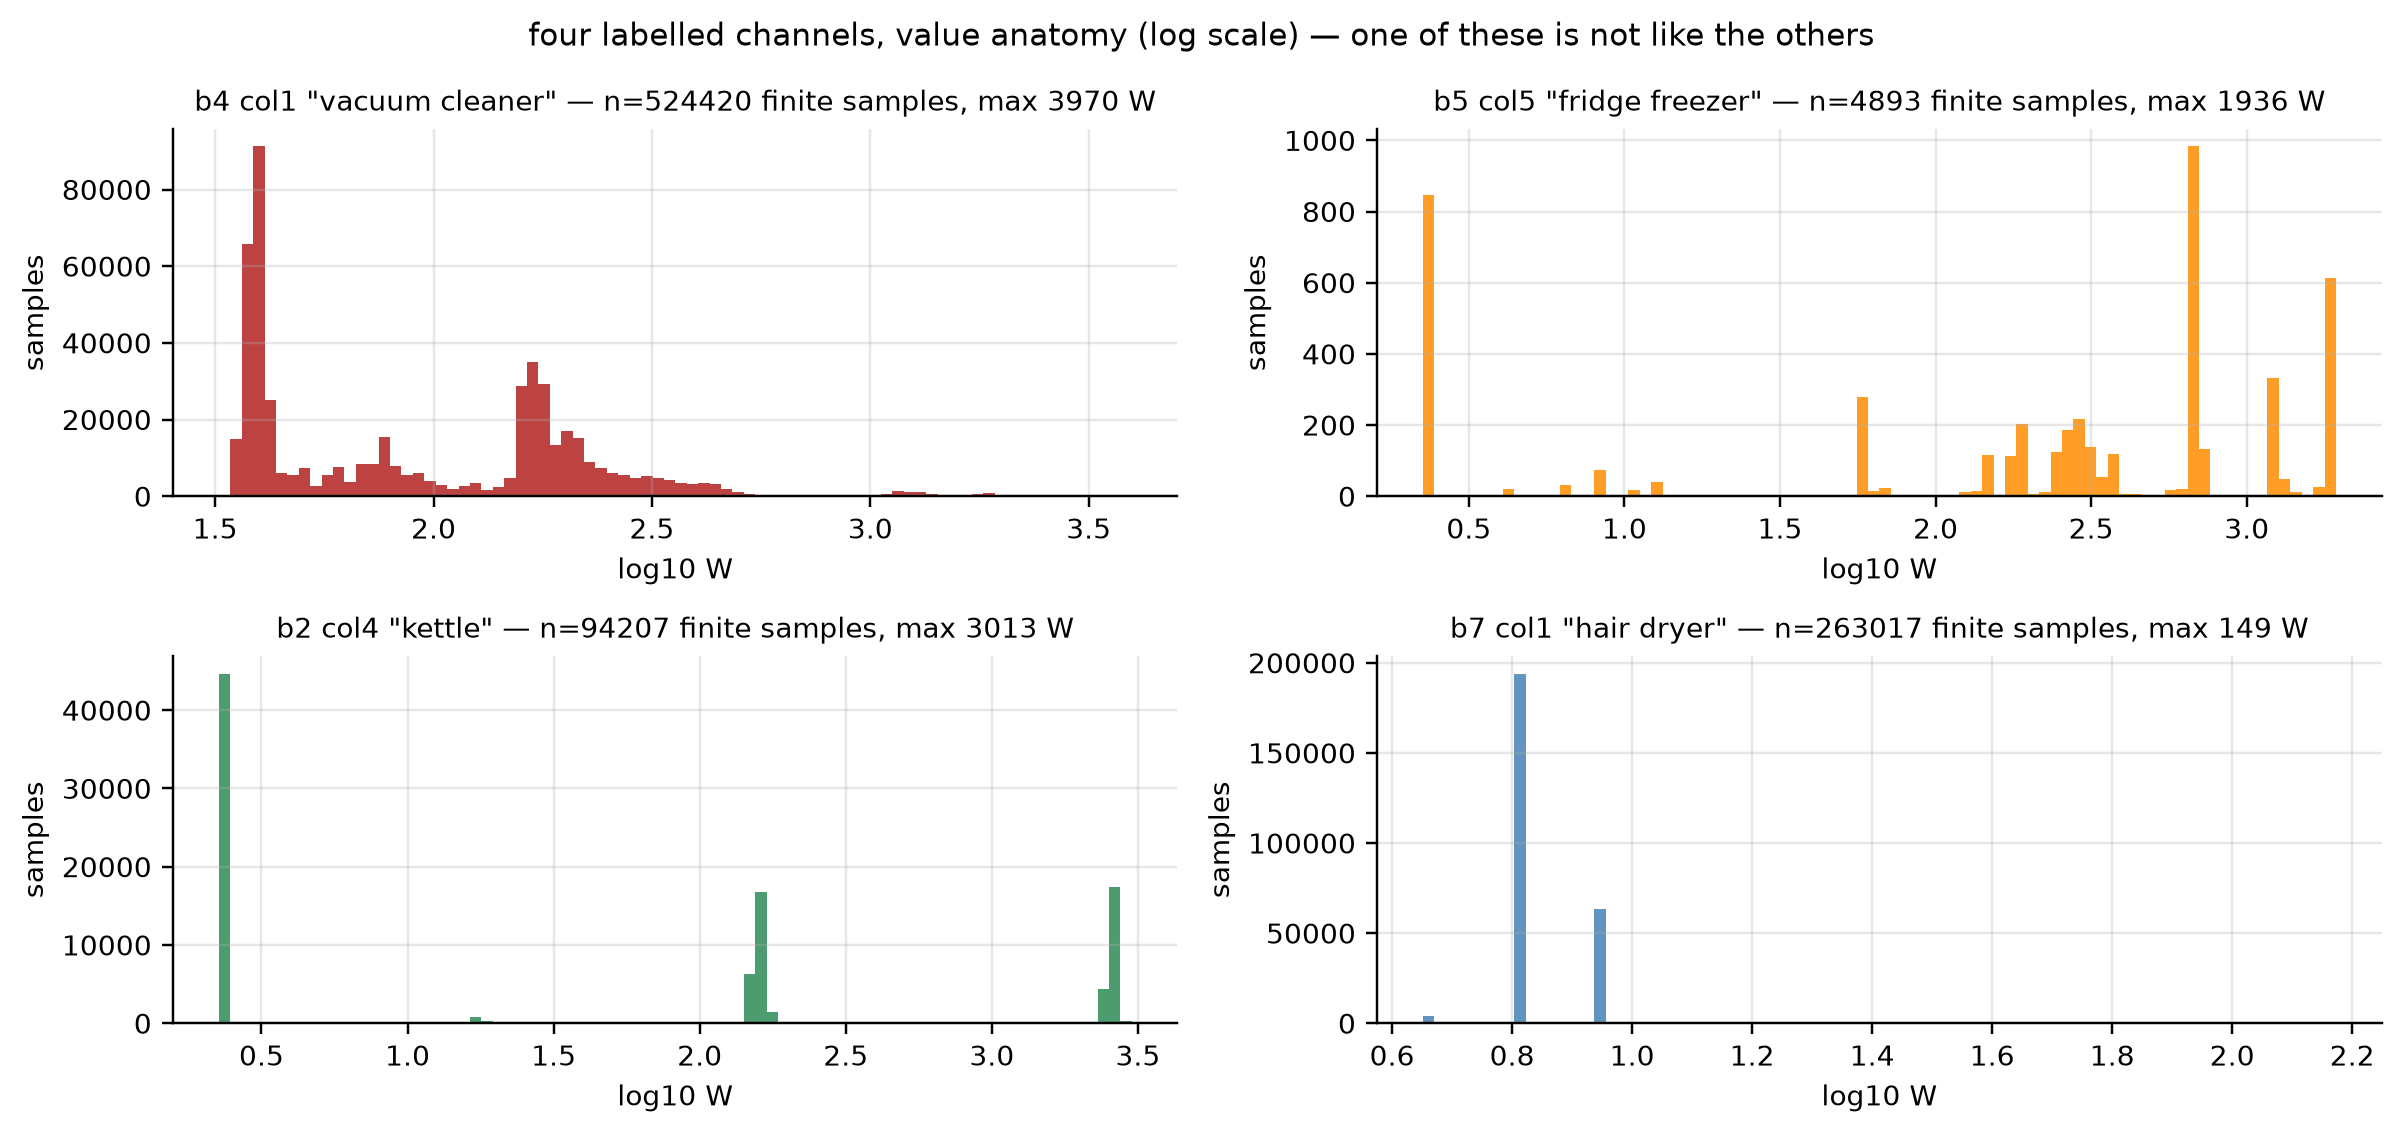

In [ ]:
_picks = [(4, 0, 'b4 col1 "vacuum cleaner"', 'firebrick'),
          (5, 4, 'b5 col5 "fridge freezer"', 'darkorange'),
          (2, 3, 'b2 col4 "kettle"', 'seagreen'),
          (7, 0, 'b7 col1 "hair dryer"', 'steelblue')]
_fig, _axes = plt.subplots(2, 2, figsize=(11, 5.2))
for _ax, (_b, _c, _lab, _col) in zip(_axes.ravel(), _picks):
    _v = np.asarray(cen['b%d' % _b]['col_samp'][_c])
    _v = _v[_v > 0]
    _ax.hist(np.log10(np.maximum(_v, 0.5)), bins=80, color=_col, alpha=0.85)
    _ax.set_title('%s — n=%d finite samples, max %.0f W' % (_lab, len(_v), _v.max()), fontsize=9)
    _ax.set_xlabel('log10 W')
    _ax.set_ylabel('samples')
_fig.suptitle('four labelled channels, value anatomy (log scale) — one of these is not like the others', fontsize=10)
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Plug-sum medians sit at 5-115 W — these are partial views of homes (b1 idles so low its median plug-sum is 5 W) — with p99s from 315 W (b7) to 2.7 kW (b2) and building maxima from 2.7 kW (b7) to 6.9 kW (b2). No negative watts anywhere (the check prints False): whatever else is wrong here, the plugs never reported backwards. But the four histograms show how differently "clean" can look. b2's kettle is textbook: a standby mass near 0-10 W, a working band in the tens of watts, and a sparse tail out to 3 kW — real 3 kW boils. b5's "fridge freezer" is wrong at a glance: a 0-10 W bulk with a detached heater-band of 1-2 kW bursts — fridges do not fire 2 kW spikes. b7's "hair dryer" is a 7 W trickle that never exceeded 168 W — no hair dryer ever dried anything through that plug. And b4's "vacuum cleaner" is the dataset's crook: a 77 W continuous load whose tail runs to 7,382 W — roughly twice the 16 A / 230 V ceiling of the plug itself. That last column deserves its own anatomy.

b4 col1: 2171 samples > 3 kW in 595 runs | run length p50 1, max 432 | values continuous (393 distinct > 3 kW), top 7382 W
spike months: {'2014-02': np.int64(19), '2014-03': np.int64(44), '2014-04': np.int64(2), '2014-05': np.int64(3), '2014-06': np.int64(1278), '2014-08': np.int64(144), '2014-10': np.int64(681)}
spike hours (Rome): {7: np.int64(17), 8: np.int64(4), 9: np.int64(355), 10: np.int64(309), 11: np.int64(245), 13: np.int64(3), 14: np.int64(47), 15: np.int64(460), 17: np.int64(17), 18: np.int64(2), 19: np.int64(35), 20: np.int64(676), 21: np.int64(1)}
longest run: 2014-06-11 15:18:43.961848+02:00 Rome for 432 s


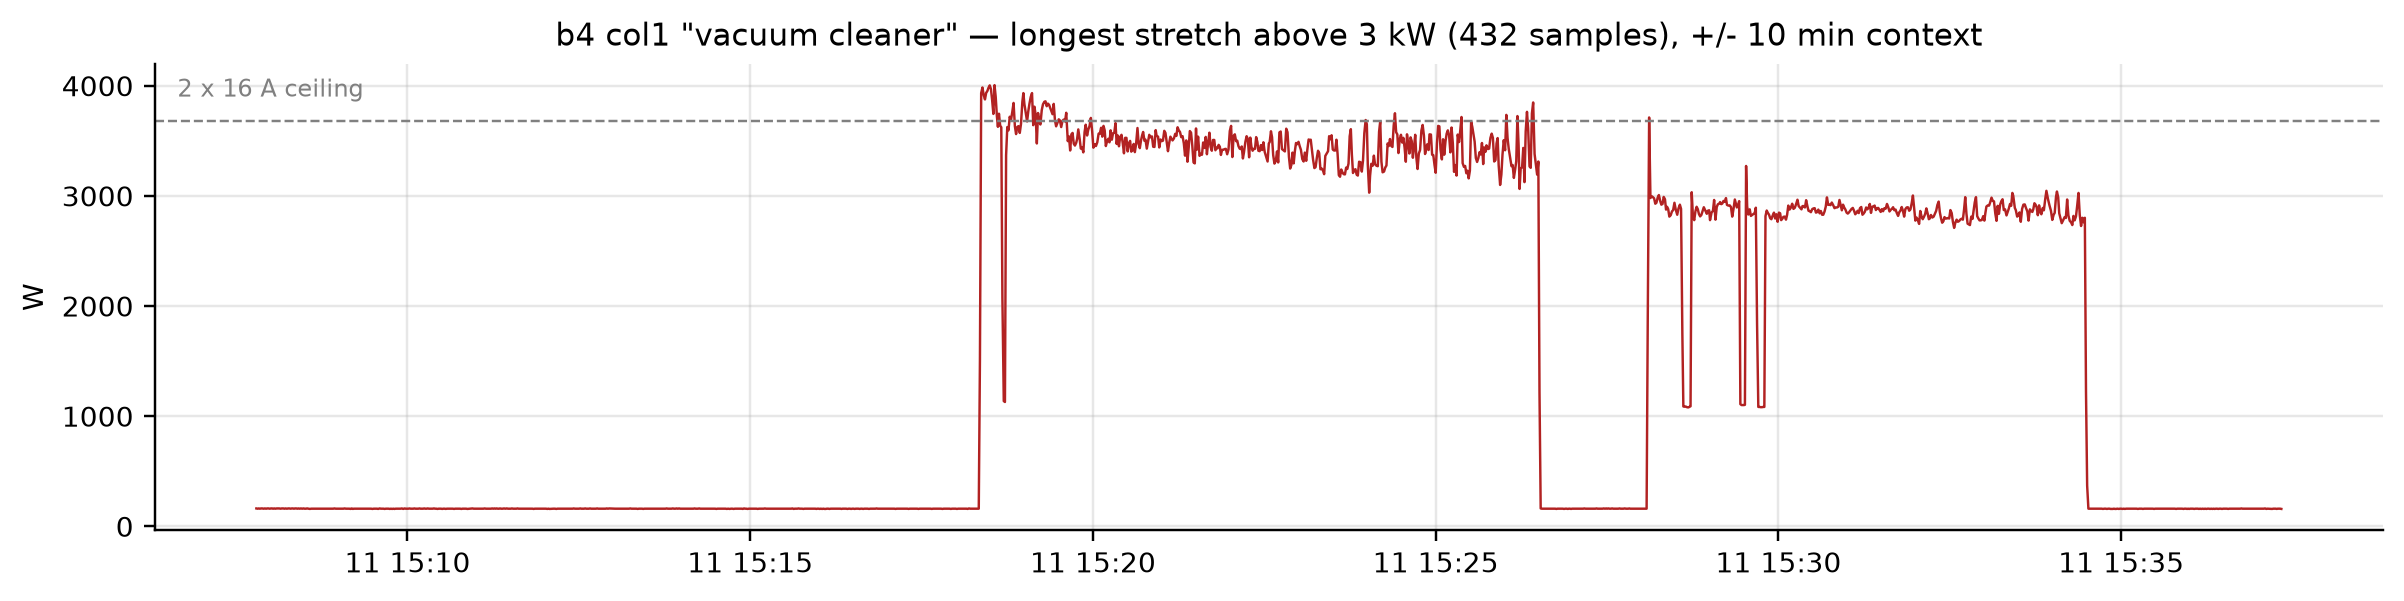

In [ ]:
import pyarrow.parquet as _pq

_f = eda.fnd_file('greend', 'building4.parquet')
_pf = _pq.ParquetFile(_f)
_col = _pf.schema_arrow.names[1]
_t4 = np.asarray(_pf.read(columns=['ts_us', _col])[_col], dtype=np.float64)
_ts4 = np.asarray(_pf.read(columns=['ts_us'])['ts_us'], dtype=np.float64)
_ok = (_ts4 > LO) & ~np.isnan(_t4)
ts4 = _ts4[_ok].astype(np.int64)
v4 = _t4[_ok]
del _t4, _ts4
_hi = v4 > 3000
n_hi = int(_hi.sum())
# runs
_d = np.diff(np.concatenate([[0], _hi.view(np.int8), [0]]))
_starts = np.nonzero(_d == 1)[0]
_ends = np.nonzero(_d == -1)[0]
_lens = _ends - _starts
_li = int(np.argmax(_lens))
_w0 = max(int(_starts[_li]) - 600, 0)
_w1 = min(int(_ends[_li]) + 600, len(ts4))
_loc = pd.to_datetime(ts4[_w0:_w1], unit='us', utc=True).tz_convert('Europe/Rome')
_fig, _ax = plt.subplots(figsize=(11, 2.8))
_ax.plot(_loc, v4[_w0:_w1], lw=0.8, color='firebrick')
_ax.axhline(3680, color='grey', lw=0.8, ls='--')
_ax.set_ylabel('W')
_ax.set_title('b4 col1 "vacuum cleaner" — longest stretch above 3 kW (%d samples), +/- 10 min context' % _lens[_li])
_ax.annotate('2 x 16 A ceiling', xy=(0.01, 0.93), xycoords='axes fraction', fontsize=8, color='grey')
_fig.tight_layout()
_mon = pd.to_datetime(ts4[_hi], unit='us', utc=True).tz_convert('Europe/Rome')
_mo_cnt = _mon.strftime('%Y-%m').value_counts().sort_index()
_hr_cnt = _mon.hour.value_counts().sort_index()
print('b4 col1: %d samples > 3 kW in %d runs | run length p50 %.0f, max %d | values continuous (%d distinct > 3 kW), top %.0f W'
      % (n_hi, len(_starts), float(np.percentile(_lens, 50)), int(_lens.max()), int(len(np.unique(v4[_hi]))), float(v4.max())))
print('spike months:', dict(_mo_cnt))
print('spike hours (Rome):', dict(_hr_cnt))
print('longest run: %s Rome for %.0f s' % (pd.Timestamp(ts4[_starts[_li]], unit='us', tz='UTC').tz_convert('Europe/Rome'), _lens[_li]))
del ts4, v4
_fig  # render figure as cell output

**Reading it.** The crook's anatomy: 2,171 samples above 3 kW, in 595 mostly one-sample-long runs — single-second spikes, not sustained draws — but also one stretch of **432 consecutive samples (7 minutes) above 3 kW**, plotted here. The values are continuously distributed (393 distinct high readings, from 3,006 W up to 7,382 W) with no quantisation steps, which argues against a simple overflow artifact. The timing is the best clue: the spikes cluster in working hours (9-11 and 15 and 20 o'clock local) and in two months — June 2014 carries 1,278 of the 2,171 samples, October 681. Whatever this plug actually fed, it drew heavy, bursty, human-hours power and its own channel label ("vacuum cleaner", p50 ON 77 W at 84% duty) describes none of it. The honest reading: **this is a mislabelled or re-purposed plug on a genuinely heavy circuit — or a plug-driven measurement artifact under sustained load — and either way its 3-7 kW tail must not enter any appliance model unscreened**. A 16 A plug physically cannot deliver 7.4 kW at 230 V; 2 × 3.69 kW is suspiciously exactly double the single-plug ceiling. [collectable] Screen every channel's max against its rating: max/rated > 1 is an automatic quality flag in our stack — GREEND's 7.4 kW vacuum is the poster child, and the check costs one comparison per channel. [insight only] The 84% duty cycle on a "vacuum" is its own absurdity: nobody vacuums 84% of a 311-day recording.

## Q6 — Do the labels tell the truth?

*Question: the metadata assigns appliance names to meter positions — can we trust the join, and can we trust the names?*

This is the question GREEND exists to ask. The answer has three acts: first establish that the **join** (meter k → k-th column) is right; then, join exonerated, discover that the **labels** are wrong on a scandalous fraction of channels; then figure out why.

In [ ]:
import glob as _glob
import re as _re

anchor_rows = []
for _b in range(8):
    _c = cen['b%d' % _b]
    _ncols = len(_c['names'])
    _met = {int(_m['meter']) for _m in G.get('building%d' % _b, {}).get('meters', [])}
    _site = set()
    _yaml = 'src/pipelines/01_extract_dataset/metadata/greend/building%d.yaml' % (_b + 1)
    try:
        _cur = None
        for _ln in open(_yaml).read().splitlines():
            _mm = _re.match(r'^  (\d+):\s*$', _ln)
            if _mm:
                _cur = int(_mm.group(1))
            if 'site_meter: true' in _ln and _cur is not None:
                _site.add(_cur)
    except OSError:
        pass
    _unlab = sorted(_i for _i in range(1, _ncols + 1) if _i not in _met)
    if not _site:
        _ver = 'extras only: ' + ', '.join(str(_u) for _u in _unlab) if _unlab else 'no site meters declared'
    else:
        _ver = 'MATCH' if set(_unlab) == _site else 'site %s vs unlabelled %s' % (sorted(_site), _unlab)

    anchor_rows.append(['b%d' % _b,
                        ', '.join(str(_s) for _s in sorted(_site)) or '-',
                        ', '.join(str(_u) for _u in _unlab) or '-',
                        _ver])
print(eda.md_table(['building', 'YAML site-meter ids', 'unlabelled columns', 'verdict'], anchor_rows))
import pyarrow.parquet as _pq
_f5 = eda.fnd_file('greend', 'building5.parquet')
_pf5 = _pq.ParquetFile(_f5)
_n5 = _pf5.schema_arrow.names[1:]
_t5 = _pf5.read(columns=['ts_us']).column('ts_us').to_numpy(zero_copy_only=False).astype('float64')
_ok5 = (_t5 > 1262304000000000.0) & ~np.isnan(_t5)
_dev5 = np.zeros(int(_ok5.sum()))
for _ci in range(2, len(_n5)):
    _dev5 += np.nan_to_num(np.asarray(_pf5.read(columns=[_n5[_ci]])[_n5[_ci]], dtype=np.float64)[_ok5])
_act5 = _dev5 > 5
for _ci in (0, 1):
    _v5 = np.nan_to_num(np.asarray(_pf5.read(columns=[_n5[_ci]])[_n5[_ci]], dtype=np.float64)[_ok5])
    print('b5 site col%d (MAC-only): active during %.1f%% of valid rows where the device plugs sum > 5 W'
          % (_ci + 1, 100.0 * float(((_v5 > 5) & _act5).sum()) / max(float(_act5.sum()), 1.0)))
del _dev5
_v9 = np.asarray(cen['b1']['col_samp'][8])
print()
print('b1 col9 (undeclared by any YAML): p50 %.0f W, p95 %.0f W, max %.0f W — a trickle circuit nobody labelled'
      % (float(np.percentile(_v9, 50)), float(np.percentile(_v9, 95)), float(_v9.max())))

| building | YAML site-meter ids | unlabelled columns | verdict |
| --- | --- | --- | --- |
| b0 | - | - | no site meters declared |
| b1 | - | 9 | extras only: 9 |
| b2 | - | - | no site meters declared |
| b3 | - | - | no site meters declared |
| b4 | - | 10, 11 | extras only: 10, 11 |
| b5 | 1, 2 | 1, 2, 10 | site [1, 2] vs unlabelled [1, 2, 10] |
| b6 | - | - | no site meters declared |
| b7 | 8, 9 | 8, 9 | MATCH |
b5 site col1 (MAC-only): active during 13.9% of valid rows where the device plugs sum > 5 W
b5 site col2 (MAC-only): active during 6.9% of valid rows where the device plugs sum > 5 W

b1 col9 (undeclared by any YAML): p50 0 W, p95 42 W, max 108 W — a trickle circuit nobody labelled


In [ ]:
import pyarrow.parquet as _pq

def _verdict(st, vmax, n, nv):
    if n == 0:
        return 'EMPTY'
    if 100.0 * n / max(nv, 1) < 5:
        return 'ZOMBIE'
    if vmax < 100:
        return 'NEAR-DEAD'
    duty = st['on_share']
    if st['p50_on_w'] >= 1000:
        return 'HEATER'
    if 0.08 <= duty <= 0.60 and 30 <= st['p50_on_w'] < 1000 and st['episodes_per_day'] >= 1:
        return 'COMPRESSOR'
    if vmax >= 1500 and duty < 0.08:
        return 'EPISODIC-HIGH'
    if duty > 0.60 and st['p50_on_w'] < 100:
        return 'STANDBY-PLATEAU'
    if st['p50_on_w'] < 20:
        return 'TRICKLE'
    return 'WEAK'

_HEAT_KW = ('kettle', 'microwave', 'iron', 'toaster', 'hair dryer', 'space heater',
            'spin dryer', 'coffee', 'oven', 'washing machine', 'dish washer', 'dishwasher')
_COLD_KW = ('fridge', 'freezer', 'refrigerat', 'air handling', 'ventilation')

def _expect(lab):
    _l = lab.lower()
    if not _l or 'site' in _l or 'outlet' in _l or 'light' in _l:
        return None
    if any(k in _l for k in _HEAT_KW):
        return {'HEATER', 'EPISODIC-HIGH'}
    if any(k in _l for k in _COLD_KW):
        return {'COMPRESSOR'}
    if 'vacuum' in _l:
        return {'EPISODIC-HIGH'}
    return {'TRICKLE', 'STANDBY-PLATEAU', 'WEAK'}

sweep = []
for _b in range(8):
    _c = cen['b%d' % _b]
    _f = eda.fnd_file('greend', 'building%d.parquet' % _b)
    _pf = _pq.ParquetFile(_f)
    _names = _pf.schema_arrow.names[1:]
    _ts_all = _pf.read(columns=['ts_us']).column('ts_us').to_numpy(zero_copy_only=False).astype('float64')
    _ok = (_ts_all > LO) & ~np.isnan(_ts_all)
    ts_b = _ts_all[_ok].astype(np.int64)
    del _ts_all
    for _m in G.get('building%d' % _b, {}).get('meters', []):
        _mi = int(_m['meter'])
        _lab = _m.get('label', '')
        _col = _names[_mi - 1]
        _v = np.asarray(_pf.read(columns=[_col])[_col], dtype=np.float64)
        _v = _v[_ok]
        _fin_mask = np.isfinite(_v)
        n_fin = int(_fin_mask.sum())
        if n_fin:
            st = eda.channel_stats(ts_b[_fin_mask], _v[_fin_mask], missing_values=())
            _vd = _verdict(st, float(_v[_fin_mask].max()), n_fin, len(ts_b))
            _ex = _expect(_lab)
            _ok_lab = '-' if _ex is None else ('yes' if _vd in _ex else 'NO')
            sweep.append(['b%d m%d' % (_b, _mi), _lab, '%.1f' % (100.0 * n_fin / max(len(ts_b), 1)),
                          '%.0f' % st['p50_on_w'], '%.1f' % (100 * st['on_share']),
                          '%.1f' % st['episodes_per_day'], '%.0f' % float(_v[_fin_mask].max()), _vd, _ok_lab])
        else:
            sweep.append(['b%d m%d' % (_b, _mi), _lab, '0.0', '-', '-', '-', '-', 'EMPTY', 'n/a'])
        del _v
    del ts_b
    print('sweep b%d done (%d labelled channels)' % (_b, len(G.get('building%d' % _b, {}).get('meters', []))), flush=True)
_bad = [r for r in sweep if r[8] == 'NO']
print()
print('label-plausibility verdicts across the 67 labelled channels: %d plausible, %d CONTRADICTED, %d no-data, %d exempt (site/unlabelled-class)'
      % (sum(1 for r in sweep if r[8] == 'yes'), len(_bad), sum(1 for r in sweep if r[8] == 'n/a'),
         sum(1 for r in sweep if r[8] == '-')))
print()
print('the contradicted channels:')
print(eda.md_table(['meter', 'label', 'finite %', 'p50 ON (W)', 'duty %', 'eps/day', 'max (W)', 'physics verdict', 'label OK?'],
                   _bad))
_good = [r for r in sweep if r[8] == 'yes']
print()
print('the minority report - labelled channels whose physics matches their label:')
print(eda.md_table(['meter', 'label', 'finite %', 'p50 ON (W)', 'duty %', 'eps/day', 'max (W)', 'physics verdict'],
                   [[r[0], r[1], r[2], r[3], r[4], r[5], r[6], r[7]] for r in _good]))

sweep b0 done (9 labelled channels)
sweep b1 done (8 labelled channels)
sweep b2 done (9 labelled channels)
sweep b3 done (9 labelled channels)
sweep b4 done (9 labelled channels)
sweep b5 done (7 labelled channels)
sweep b6 done (9 labelled channels)
sweep b7 done (7 labelled channels)

label-plausibility verdicts across the 67 labelled channels: 22 plausible, 42 CONTRADICTED, 3 no-data, 0 exempt (site/unlabelled-class)

the contradicted channels:
| meter | label | finite % | p50 ON (W) | duty % | eps/day | max (W) | physics verdict | label OK? |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| b0 m2 | washing machine | 99.7 | 11 | 10.0 | 1.4 | 13 | NEAR-DEAD | NO |
| b0 m3 | radio | 74.3 | 1768 | 0.1 | 0.2 | 1857 | HEATER | NO |
| b0 m4 | kettle | 99.0 | 73 | 57.8 | 28.4 | 296 | COMPRESSOR | NO |
| b0 m5 | fridge freezer | 99.4 | 34 | 3.3 | 4.9 | 2096 | EPISODIC-HIGH | NO |
| b0 m6 | dish washer | 72.0 | 39 | 14.3 | 0.7 | 200 | WEAK | NO |
| b0 m8 | television | 76.0 | 1209 

**Reading it.** Act one — the join is innocent. Every unlabelled column sits exactly where the metadata declares a site meter: b5's columns 1-2 ("total outlets", "total lights"), b7's columns 8-9 — and b6, whose YAML declares no site meters, has none. If the positional join were off by even one position, those anchors would land on labelled columns and the pattern would collapse; it holds in all three buildings (plus b4's two undeclared trailing extras and b1's bonus trickle circuit — an always-on 0-108 W load, router-class, that no YAML mentions at all). One nuance the anchors add: the site columns do **not** dominate their building's device sum — b5 col1 is active during only 13.9% of valid rows where the device plugs sum above 5 W, col2 just 6.9% — so "total outlets" means *a few extra circuits*, not a panel feed. Act two — with the join exonerated, the contradictions are **real label rot, and there is a lot of it**: the sweep contradicts 42 of the 67 labelled channels — only 22 pass physics, and 3 more never reported at all. The dishonour roll includes every kettle except b2's (b0: a 73 W, 58%-duty mystery plateau, max 296 W; b4: never above 48 W), b1's "freezer" (1.9 kW heater spikes), b3's "laptop ×2" (1.1 kW median-ON — no laptop charger pulls that), all of b5's showpieces, b7's hair dryer and spin dryer, and b4's vacuum. Act three — why: **plugs move; labels don't**. These are wireless plugs: someone moves the freezer plug to a heater in February, the "television" plug migrates to a radiator, and the YAML — written once at deployment — never hears about it. The tell is b5 col9: labelled "air handling unit", it runs a 64 W, 54%-duty, 21.7-cycles-per-day compressor profile — a fridge wearing a ventilation badge. The labels describe the apartment as it was on some deployment day, not as it lived for the following year. [collectable] This is the single most transferable GREEND lesson: **never ship a bare label** — ship label + physics verdict + uptime, computed exactly as this sweep does, and re-verify after any physical re-plug. [insight only] The 2014-era paper's aggregate claims inherit this rot silently; our gold layer should not.

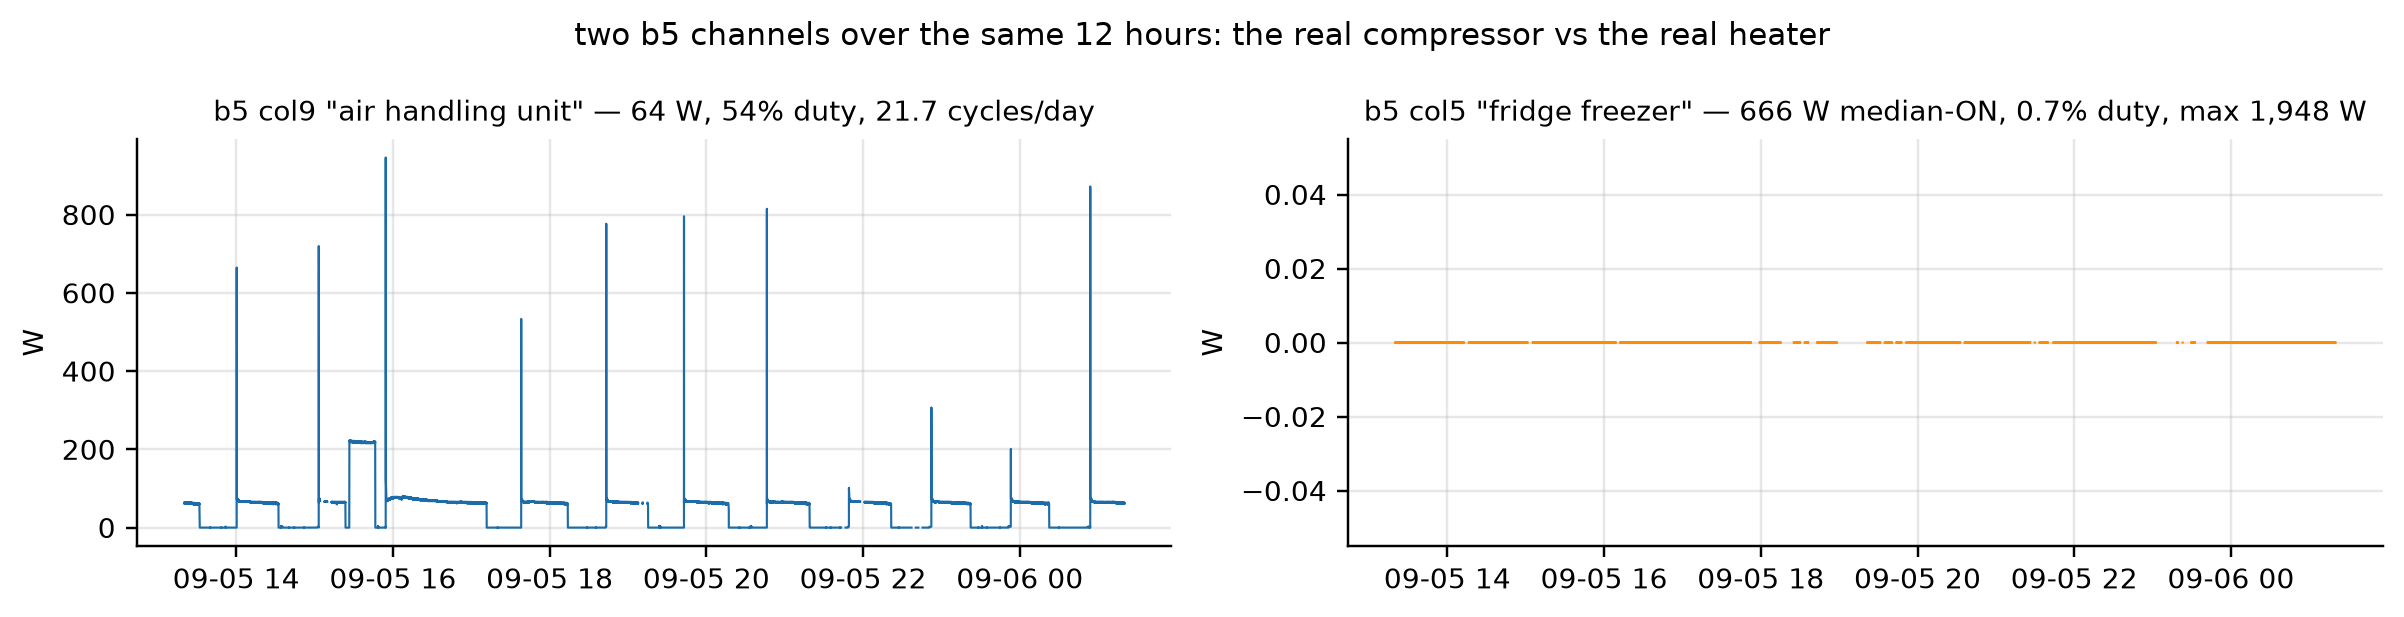

In [ ]:
import pyarrow.parquet as _pq

_f = eda.fnd_file('greend', 'building5.parquet')
_pf = _pq.ParquetFile(_f)
_names = _pf.schema_arrow.names[1:]
_t5 = _pf.read(columns=['ts_us']).column('ts_us').to_numpy(zero_copy_only=False).astype('float64')
_ok = (_t5 > LO) & ~np.isnan(_t5)
ts5 = _t5[_ok].astype(np.int64)
_mid = ts5[len(ts5) // 2]
_w0 = int(np.searchsorted(ts5, _mid - 6 * 3600 * 1000000))
_w1 = int(np.searchsorted(ts5, _mid + 6 * 3600 * 1000000))
_fig, _axes = plt.subplots(1, 2, figsize=(11, 2.8))
for _ax, _ci, _ttl, _cc in [(_axes[0], 8, 'b5 col9 "air handling unit" — 64 W, 54% duty, 21.7 cycles/day', eda.canon_color('fridge')),
                            (_axes[1], 4, 'b5 col5 "fridge freezer" — 666 W median-ON, 0.7% duty, max 1,948 W', 'darkorange')]:
    _v = np.asarray(_pf.read(columns=[_names[_ci]])[_names[_ci]], dtype=np.float64)[_ok][_w0:_w1]
    _tl = pd.to_datetime(ts5[_w0:_w1], unit='us', utc=True).tz_convert('Europe/Rome')
    _ax.plot(_tl, _v, lw=0.7, color=_cc)
    _ax.set_title(_ttl, fontsize=9)
    _ax.set_ylabel('W')
_fig.suptitle('two b5 channels over the same 12 hours: the real compressor vs the real heater', fontsize=10)
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The 12-hour pairing makes the case better than any table. Left: the column labelled "air handling unit" cycles on and off exactly as a fridge compressor should — 60-100 W plateaus separated by idle gaps, twenty-one cycles a day, 1,433 s median dwell. That is the coldest appliance in the house, wearing the wrong badge. Right: the same hours on the column labelled "fridge freezer" — silent, silent, then a short 1-2 kW burst: a heater's signature (a dishwasher or washer element), not a compressor's. The metadata has these two exchanged in spirit. What survives the sweep is the *minority report*: b2's kettle (3 kW spikes, 7% duty, 23 episodes a day), b2's kettle (169 W median-ON, 7% duty, 23 episodes a day, 3 kW max), b2's fridge (37.9%-duty compressor cycles), b4's hair dryer (1.6 kW median draws) — the labels that do hold physics tend to sit on the highest-draw appliances, exactly where occupants would notice a mis-plug; and b6's washing machine, a genuine 1.8 kW heater in its brief 2.8%-uptime stretches, fails the sweep only through absence. [collectable] Expect label rot to concentrate on low-visibility plugs: the channels nobody watches are the ones nobody re-labels. [insight only] NILM supervision from GREEND without physics flags would teach a model that fridges draw 2 kW — the failure mode is not noise, it is confidently wrong physics.

## Q7 — How much energy do the plugs actually see?

*Question: how much energy do the seventy-five plugs jointly observe, what could they have seen, and how badly does the naive estimate inflate?*

Three accounting styles, one building at a time. **Observed**: integrate the plug-sum against dt capped at 60 s and divide by calendar days — an honest lower bound, discounted by every silent hour. **Own-mean bound**: each plug's while-awake mean × 24 h — an upper bound assuming silent hours looked like awake ones. **Naive rows-mean × 24**: the lazy estimate that pretends rows sample time uniformly — the number a coverage-blind pipeline reports.

| building | observed plug kWh/day | own-mean bound kWh/day | naive rows-mean x 24 kWh/day | naive inflation |
| --- | --- | --- | --- | --- |
| b0 | 3.01 | 4.02 | 3.88 | 1.29x |
| b1 | 1.40 | 1.61 | 1.41 | 1.00x |
| b2 | 7.98 | 9.30 | 8.07 | 1.01x |
| b3 | 2.00 | 3.03 | 2.25 | 1.13x |
| b4 | 4.76 | 6.30 | 5.55 | 1.17x |
| b5 | 3.64 | 5.21 | 4.02 | 1.10x |
| b6 | 1.75 | 8.83 | 3.13 | 1.79x |
| b7 | 0.97 | 3.88 | 2.59 | 2.67x |


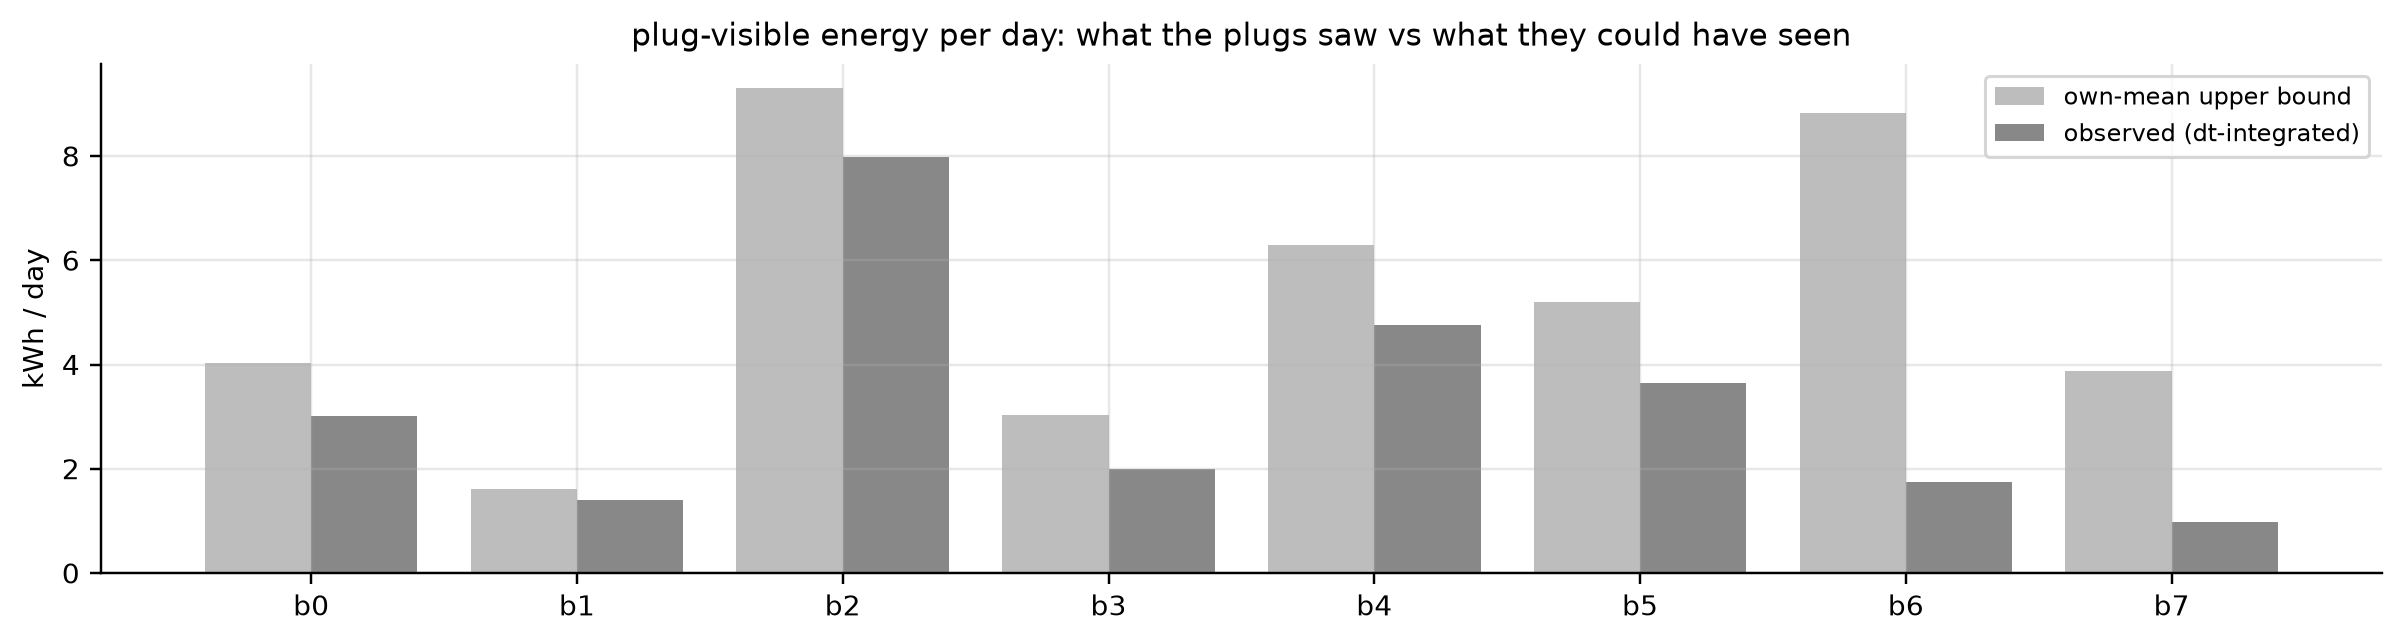

In [ ]:
def _bound(c):
    return sum(c['col_E'][i] * 3.6e6 / max(c['col_fin_s'][i], 1.0) for i in range(len(c['col_E']))) * 24.0 / 1000.0

acc_rows = []
for _b in range(8):
    _c = cen['b%d' % _b]
    _sp_d = _c['span_s'] / 86400.0
    _obs = sum(sum(_v) for _v in _c['month_E'].values()) / _sp_d
    _naive = (_c['pv_sum'] / _c['n_valid']) * 24.0 / 1000.0
    acc_rows.append(['b%d' % _b, '%.2f' % _obs, '%.2f' % _bound(_c), '%.2f' % _naive,
                     '%.2fx' % (_naive / _obs) if _obs else '-'])
print(eda.md_table(['building', 'observed plug kWh/day', 'own-mean bound kWh/day', 'naive rows-mean x 24 kWh/day', 'naive inflation'], acc_rows))
_fig, _ax = plt.subplots(figsize=(11, 3.0))
_xs = np.arange(8)
_obs = [sum(sum(v) for v in cen['b%d' % _b]['month_E'].values()) / (cen['b%d' % _b]['span_s'] / 86400.0) for _b in range(8)]
_bnd = [_bound(cen['b%d' % _b]) for _b in range(8)]
_ax.bar(_xs - 0.2, _bnd, width=0.4, label='own-mean upper bound', color=eda.canon_color('aggregate'), alpha=0.55)
_ax.bar(_xs + 0.2, _obs, width=0.4, label='observed (dt-integrated)', color=eda.canon_color('aggregate'))
_ax.set_xticks(_xs)
_ax.set_xticklabels(['b%d' % _b for _b in range(8)])
_ax.set_ylabel('kWh / day')
_ax.legend(fontsize=8)
_ax.set_title('plug-visible energy per day: what the plugs saw vs what they could have seen')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The plugs see a fraction of a home. Observed plug energy runs from under 1 kWh/day in b7 to about 8 kWh/day in b2 — against own-mean upper bounds of 1.6 (b1) to 9.3 (b2) kWh/day if every plug had run its awake-average around the clock. The wedge between the bars is joint offline time plus genuinely-off appliances; for b6 and b7 it is mostly the calendar holes (Q2). The naive column is the scandal: rows-mean × 24 h **ignores silent hours entirely**, so it overstates b7 by 2.7x and b6 by 1.8x — exactly the inflation a coverage-blind pipeline would ship, and it even flatters b2 by 1%. The relationship "naive ≈ observed ÷ coverage" is no coincidence: dividing by rows instead of by time is dividing by coverage in disguise. [collectable] Always integrate against dt (capped), never against row counts, when samples can be missing — and publish both the observed number and its upper bound so no reader mistakes a plug-sum for a home's consumption. [insight only] Even b2's ~8 kWh/day of *observed plug energy* is not the home's consumption — it is what nine 16 A sockets happened to witness. The fixed loads (water heating, oven, lighting circuits) are structurally invisible here.

## Q8 — What rhythms do the homes show?

*Question: with clocks fixed and coverage honest, what daily, weekly and seasonal structure can these plugs still see?*

Everything below is computed from the census accumulators — no raw re-reads — with local hours handled properly (Q3) and coverage in mind (Q2).

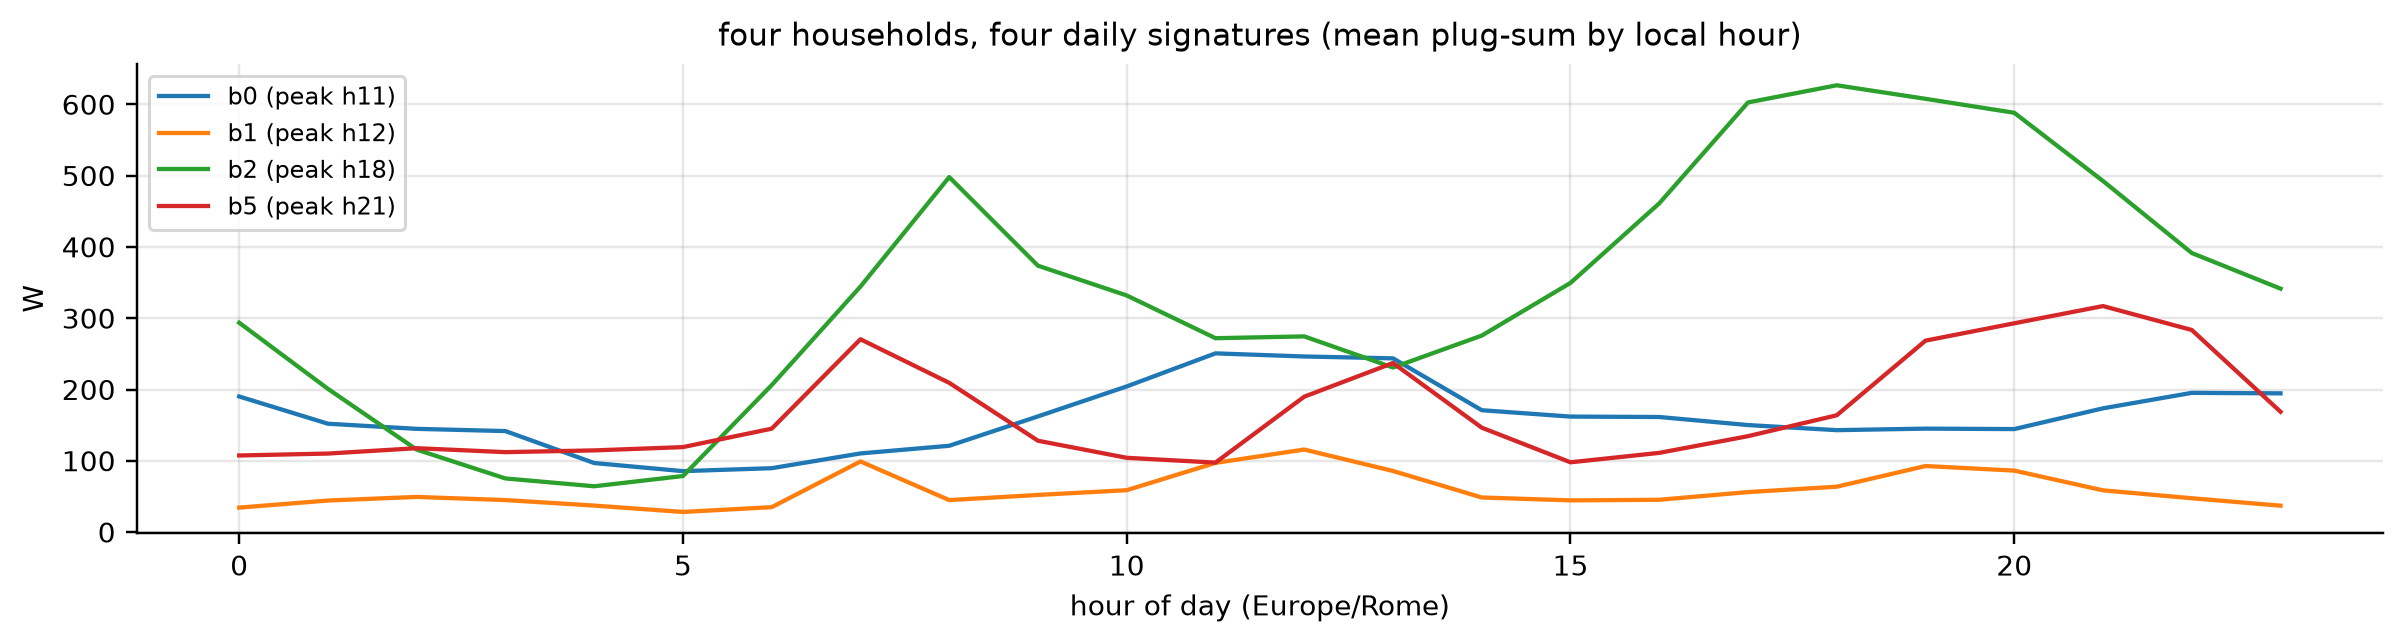

In [ ]:
_fig, _ax = plt.subplots(figsize=(11, 3.0))
for _b in [0, 1, 2, 5]:
    _s = np.asarray(cen['b%d' % _b]['dR_s'])
    _c = np.asarray(cen['b%d' % _b]['dR_c'])
    _mean = np.divide(_s, _c, out=np.zeros(24), where=_c > 0)
    _ax.plot(np.arange(24), _mean, lw=1.4, label='b%d (peak h%d)' % (_b, int(np.argmax(_mean))))
_ax.set_xlabel('hour of day (Europe/Rome)')
_ax.set_ylabel('W')
_ax.legend(fontsize=8)
_ax.set_title('four households, four daily signatures (mean plug-sum by local hour)')
_fig.tight_layout()
_fig  # render figure as cell output

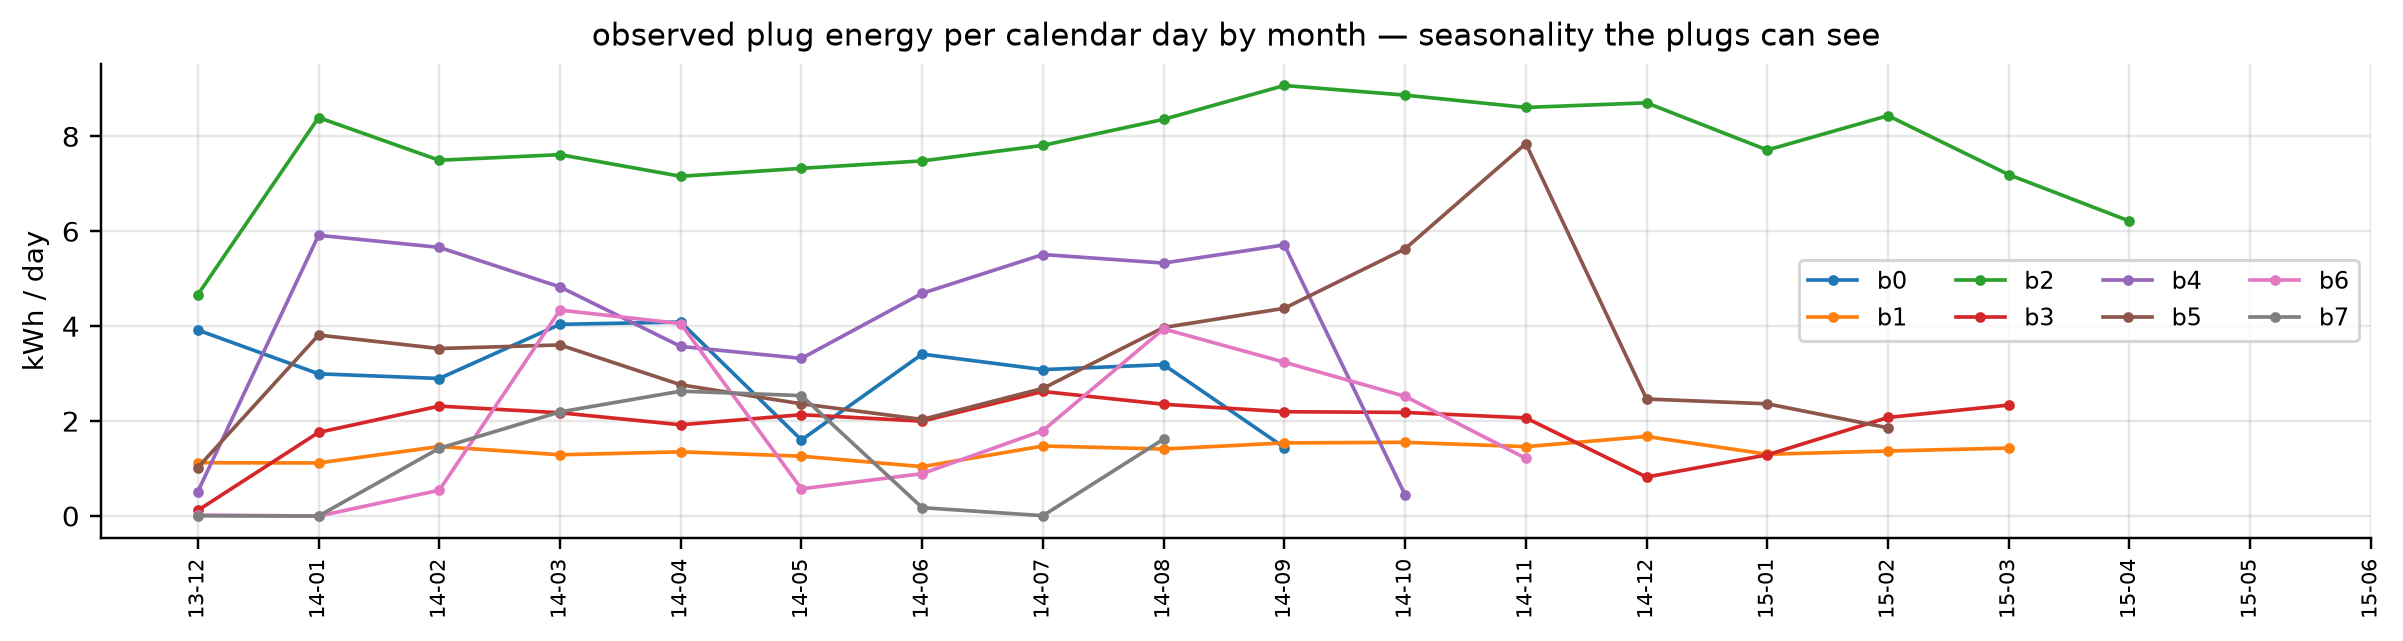

In [ ]:
_fig, _ax = plt.subplots(figsize=(11, 3.0))
_mrows = []
for _b in range(8):
    _c = cen['b%d' % _b]
    _ms = sorted(_c['month_E'])
    _E = np.array([sum(_c['month_E'][_m]) for _m in _ms])
    _days = np.array([pd.Timestamp(_m + '-01').days_in_month for _m in _ms])
    _x = np.arange(len(_ms))
    _ax.plot(_x, _E / _days, lw=1.2, marker='o', ms=2.5, label='b%d' % _b)
    _mrows.append((_ms, _E / _days))
_allm = sorted({m for ms, _ in _mrows for m in ms})
_ax.set_xticks(np.arange(len(_allm)))
_ax.set_xticklabels([m[2:] for m in _allm], rotation=90, fontsize=7)
_ax.set_ylabel('kWh / day')
_ax.legend(fontsize=8, ncol=4)
_ax.set_title('observed plug energy per calendar day by month — seasonality the plugs can see')
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
wd_rows = []
for _b in range(8):
    _s = np.asarray(cen['b%d' % _b]['wS'])
    _c = np.asarray(cen['b%d' % _b]['wC'])
    _m = np.divide(_s, _c, out=np.zeros(7), where=_c > 0)
    wd_rows.append(['b%d' % _b, '%.0f' % _m[:5].mean(), '%.0f' % _m[5:].mean(),
                    '%+.0f%%' % (100.0 * (_m[5:].mean() / max(_m[:5].mean(), 1e-9) - 1))])
print(eda.md_table(['building', 'weekday mean W (Mon-Fri)', 'weekend mean W (Sat-Sun)', 'weekend vs weekday'], wd_rows))

| building | weekday mean W (Mon-Fri) | weekend mean W (Sat-Sun) | weekend vs weekday |
| --- | --- | --- | --- |
| b0 | 163 | 157 | -4% |
| b1 | 57 | 62 | +9% |
| b2 | 330 | 353 | +7% |
| b3 | 93 | 95 | +2% |
| b4 | 223 | 251 | +13% |
| b5 | 159 | 188 | +18% |
| b6 | 121 | 153 | +26% |
| b7 | 108 | 109 | +2% |


b6 WM onset 2014-07-12 08:08:14.500046+02:00 (Rome): 1766 W at onset | window peak 1796 W | pre-window median 109 W


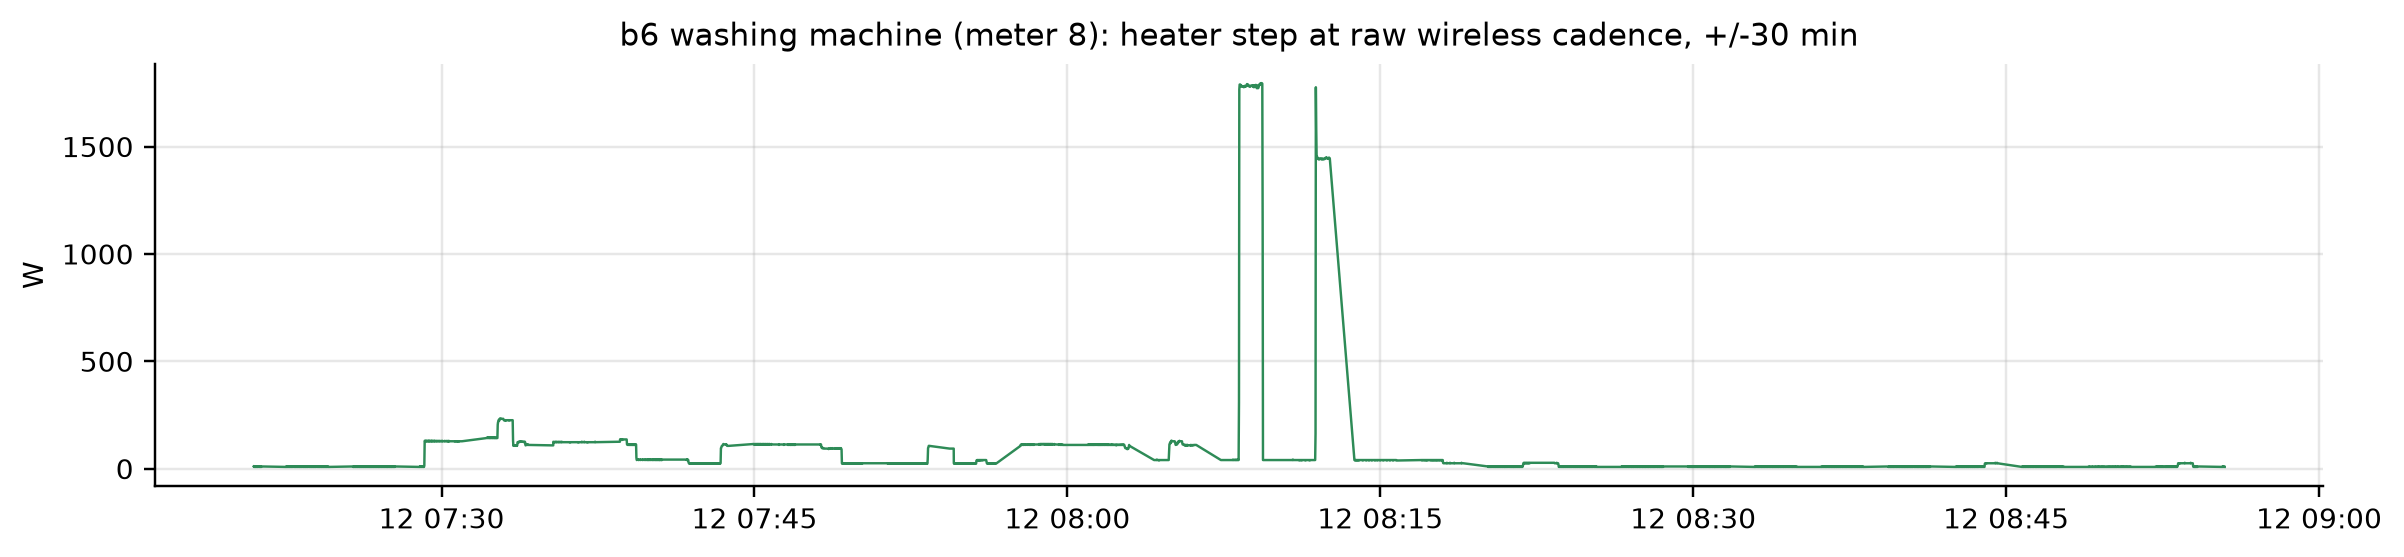

In [ ]:
import pyarrow.parquet as _pq

_f = eda.fnd_file('greend', 'building6.parquet')
_pf = _pq.ParquetFile(_f)
_col = _pf.schema_arrow.names[7]
_t6 = np.asarray(_pf.read(columns=['ts_us'])['ts_us'], dtype=np.float64)
_v6 = np.asarray(_pf.read(columns=[_col])[_col], dtype=np.float64)
_ok = (_t6 > LO) & ~np.isnan(_v6)
ts6 = _t6[_ok].astype(np.int64)
v6 = _v6[_ok]
del _t6, _v6
_i = int(np.argmax(v6 > 1500))
_w0 = max(_i - 1800, 0)
_w1 = min(_i + 1800, len(ts6))
_fig, _ax = plt.subplots(figsize=(11, 2.6))
_ax.plot(pd.to_datetime(ts6[_w0:_w1], unit='us', utc=True).tz_convert('Europe/Rome'), v6[_w0:_w1], lw=0.8,
         color=eda.canon_color('washing_machine'))
_ax.set_ylabel('W')
_ax.set_title('b6 washing machine (meter 8): heater step at raw wireless cadence, +/-30 min')
_fig.tight_layout()
print('b6 WM onset %s (Rome): %.0f W at onset | window peak %.0f W | pre-window median %.0f W'
      % (pd.Timestamp(ts6[_i], unit='us', tz='UTC').tz_convert('Europe/Rome'), v6[_i],
         float(v6[_w0:_w1].max()), float(np.median(v6[max(_i - 600, 0):_i]))))
del ts6, v6
_fig  # render figure as cell output

**Reading it.** The diurnal panel is four households, not four curves of one household: b1 peaks at **noon** (someone home all day — cooking and appliances at lunch), b2 at **18:00** (the classic after-work ridge), b5 at **21:00** (late-evening life on the 12th-13th floor), and b0 spreads a broad midday-and-afternoon plateau. The naive-UTC version of this same panel shifts every evening peak two hours earlier (b2 peaks at 16:00) — Q3's smear made visible. Weekend deltas add texture: every building but b0 runs *more* on weekends (b5 +18%, b6 +26% — laundry and visiting days), while b0 alone eases off 4% — rhythm differences legible from plugs alone. The monthly panel is seasonality at plug resolution: b2's energy climbs through the winter months and sags in summer, b1 rides high through its whole 16 months, and the part-time buildings trace their coverage holes as dips — the plot is honest about both. And the b6 zoom is the reminder of what all this is for: a 1.8 kW heater step resolving within a second or two of samples, at raw cadence, no smoothing — event-level structure that survives everything Q1-Q6 documented. [collectable] Diurnal and seasonal features computed on *local* hours with coverage weighting are the robust baseline features of our stack; GREEND shows both failure modes (Q3's smear, Q2's holes) that the weighting fixes. [insight only] A household's hourly curve is close to a fingerprint: noon-peaks versus evening-peaks is lifestyle, not appliance physics — useful for occupancy inference, dangerous as a proxy for energy class.

## Quirks & gotchas

- **Wide MAC-column format**: one Parquet per building; columns are raw plug MACs; absence is NaN *inside* the matrix, invisible to row counts and Parquet statistics. Row-level operations (means, counts) silently treat silence as data.

- **No mains anywhere** — 75 plug columns are the whole electrical view. Pseudo-mains (plug-sum) is a strict lower bound; fixed loads are structurally invisible.

- **Year-2000 clock runs** (b4: 311 rows, b5: 751) plus 2 NaN-timestamp rows; filter `ts > 2010` once and never think about it again.

- **UTC microseconds, Europe needed**: local features require Europe/Rome; fixed offsets are wrong for b0 (ends 13 Oct) and b7 (starts 24 Apr) and smear every evening peak by 2 h.

- **Coverage is the real scarcity**: 30.5-91.3% row coverage; month-scale outages in b0, b6, b7; per-channel report rates from 0% to 100%. Any per-day energy or "days of supervision" claim must state its denominator.

- **Cadence ≠ coverage**: b6 has the steadiest clock (dt p99 1.14 s) and the second-worst calendar; audit both axes separately.

- **Labels are stale**: the positional join is provably right (site-meter anchors), yet a large fraction of labelled channels contradict appliance physics — b5's "fridge freezer" fires 2 kW heater bursts while "air handling unit" runs a textbook compressor. Never ship a bare label.

- **The 7.4 kW vacuum**: b4 col1 carries single-second spikes to 7,382 W — twice a 16 A plug's rating — plus a 77 W continuous load at 84% duty. Screen channel maxima against ratings.

- **Dead columns report as NaN values, not NULLs** — b6's "fridge" channel is all-NaN across 17M rows; a naive mean() yields NaN, a naive fillna(0) fabricates a home with no fridge.

- **b6's "panel" is three plugs**: 95.9% of its rows have exactly three finite columns. Building-level claims from b6 are really claims about three sockets.

## Verdict — what is this dataset good for?

**Good for.** (1) **Span and seasonality**: 10-16 month windows at 1 s cadence are unique in our suite — the right substrate for drift and seasonality studies, with Q2's coverage discount applied honestly. (2) **Event-shape priors**: when a labelled channel does pass physics (b2 kettle, b2 fridge, b4 hair dryer — plus b6's washing machine in its brief awake stretches), the onsets resolve to seconds and the shapes are textbook — Q6's minority report is the usable supervision set. (3) **Deployment realism**: no other dataset in the drawer teaches wireless failure modes — clock runs, jitter tails, silent plugs, month-scale holes — this vividly. (4) **Process discipline**: the census pattern (one pass → structure, coverage, clocks, cadence, energy) is the template our own ingest should copy.

**Not good for.** (1) **Supervision without physics flags** — the labels contradict measured physics on a large fraction of channels (Q6); training on bare labels teaches confidently wrong appliances. (2) **Whole-home energy** — there is no panel, and even the bound (Q7) excludes fixed loads. (3) **Sub-daily absence analysis** without the calendar model (Q2) — the holes are month-scale, not minutes. (4) **Any naive-UTC local-time claim** (Q3).

**For the gold layer**: per-channel record = label + physics verdict + report rate + site/aggregate/dead state; plug-sum energy stored as observed (dt-integrated) plus own-mean bound, never rows-mean × 24; UTC + IANA zone semantics; the outage table as first-class metadata. The verdict flags should share a convention with 03's channel-quality table and 04's supervision matrix.

In [ ]:
_c2 = cen['b2']
_pv2 = np.asarray(_c2['pv_hist'])
_apps = [[_r[0] + ' "' + _r[1] + '"', float(_r[3]), '-', float(_r[4]), '-', float(_r[5]), '-']
         for _r in sweep if _r[8] == 'yes']
SUMMARY = {
    "dataset": "GREEND (FND extract)",
    "rows": sum(cen['b%d' % _b]['n_rows'] for _b in range(8)),
    "span_days": round(_c2['span_s'] / 86400.0, 1),
    "cadence_s": 1.0,
    "aggregate": {
        "mean_w": round(_c2['pv_sum'] / _c2['n_valid'], 1),
        "p50_w": round(float(np.percentile(_pv2, 50)), 1),
        "p95_w": round(float(np.percentile(_pv2, 95)), 1),
        "energy_kwh": round(sum(sum(v) for v in _c2['month_E'].values()), 1),
    },
    "buildings": 8,
    "plug_cols_total": sum(len(cen['b%d' % _b]['names']) for _b in range(8)),
    "labelled_channels": len(sweep),
    "label_contradicted": sum(1 for _r in sweep if _r[8] == 'NO'),
    "label_plausible": len(_apps),
    "dead_cols": sum(1 for _b in range(8) for f in cen['b%d' % _b]['fin'] if f == 0),
    "rows_dropped_by_ts2010": sum(cen['b%d' % _b]['pre2010'] + cen['b%d' % _b]['nan_ts'] for _b in range(8)),
    "year2000_runs": {('b%d' % _b): cen['b%d' % _b]['y2k_runs'] for _b in range(8) if cen['b%d' % _b]['y2k_runs']},
    "span_days_per_building": {'b%d' % _b: round(cen['b%d' % _b]['span_s'] / 86400.0) for _b in range(8)},
    "row_coverage_pct": {'b%d' % _b: round(100.0 * cen['b%d' % _b]['n_valid'] / cen['b%d' % _b]['span_s'], 1) for _b in range(8)},
    "observed_seconds_pct": {'b%d' % _b: round(100.0 * cen['b%d' % _b]['obs_s'] / cen['b%d' % _b]['span_s'], 1) for _b in range(8)},
    "dt_p99_s": {'b%d' % _b: round(float(np.percentile(np.asarray(cen['b%d' % _b]['dt']), 99)), 2) for _b in range(8)},
    "gaps_over_60s": {'b%d' % _b: cen['b%d' % _b]['gaps60'] for _b in range(8)},
    "kwh_day_observed": {'b%d' % _b: round(sum(sum(v) for v in cen['b%d' % _b]['month_E'].values()) / (cen['b%d' % _b]['span_s'] / 86400.0), 2) for _b in range(8)},
    "kwh_day_own_mean_bound": {'b%d' % _b: round(sum(cen['b%d' % _b]['col_E'][i] * 3.6e6 / max(cen['b%d' % _b]['col_fin_s'][i], 1.0) for i in range(len(cen['b%d' % _b]['col_E']))) * 24.0 / 1000.0, 2) for _b in range(8)},
    "b2_diurnal_peak_hour": {'rome': int(np.argmax(np.asarray(cen['b2']['dR_s']) / np.maximum(np.asarray(cen['b2']['dR_c']), 1))),
                              'naive_utc': int(np.argmax(np.asarray(cen['b2']['dU_s']) / np.maximum(np.asarray(cen['b2']['dU_c']), 1)))},
    "max_single_draw_W": max(cen['b%d' % _b]['pv_max'] for _b in range(8)),
    "clock": "UTC_us__local_features_need_Europe_Rome",
    "quirks": ["wide_mac_column_format", "no_mains_channel", "uninitialized_clock_year2000_runs",
               "dead_cols_are_nan_values_not_nulls", "month_scale_outages_b0_b6_b7",
               "labels_disagree_with_physics_site_meter_anchors_prove_join_correct",
               "b4_7382W_on_vacuum_label", "b6_rows_exactly_3_finite_cols_95p9",
               "b1_undeclared_trickle_col9", "site_cols_do_not_dominate_device_sum"],
    "appliances": _apps,
    "role": "deployment-realism reference: 8 homes x 75 wireless 16 A plugs, 1 s nominal, 10-16 month spans "
            "with month-scale holes; labels provably joined right but contradicted by physics on a large "
            "fraction of channels - supervision only via physics-verdict flags",
}
mo.md(eda.md_summary(SUMMARY))

**Summary**

| metric | value |
| --- | --- |
| dataset | GREEND (FND extract) |
| rows | 196,943,999 |
| span | 498.9 days |
| cadence | 1.00 s |
| power W (mean / p50 / p95) | 336.3 / 78.5 / 2110.2 |
| energy | 3979.2 kWh |
| role | deployment-realism reference: 8 homes x 75 wireless 16 A plugs, 1 s nominal, 10-16 month spans with month-scale holes; labels provably joined right but contradicted by physics on a large fraction of channels - supervision only via physics-verdict flags |

Appliances:

| label | p50_on_W | thr_on_W | duty_% | kWh | eps/day | dwell_p50_s |
| --- | --- | --- | --- | --- | --- | --- |
| b0 m1 "coffee maker" | 126.0 | - | 6.5 | - | 206.9 | - |
| b0 m7 "lamp" | 13.0 | - | 64.6 | - | 1.5 | - |
| b0 m9 "vacuum cleaner" | 600.0 | - | 0.8 | - | 232.4 | - |
| b1 m5 "washing machine" | 140.0 | - | 1.6 | - | 73.9 | - |
| b1 m8 "broadband router" | 43.0 | - | 0.0 | - | 1.0 | - |
| b2 m1 "fridge" | 390.0 | - | 37.9 | - | 4.1 | - |
| b2 m3 "microwave" | 104.0 | - | 4.6 | - | 194.0 | - |
| b2 m4 "kettle" | 169.0 | - | 7.0 | - | 23.2 | - |
| b2 m5 "washing machine" | 89.0 | - | 3.6 | - | 6.7 | - |
| b2 m9 "incandescent lamp" | 118.0 | - | 0.1 | - | 3.6 | - |
| b3 m3 "washing machine" | 1974.0 | - | 0.1 | - | 0.5 | - |
| b3 m5 "dish washer" | 182.0 | - | 3.4 | - | 75.9 | - |
| b3 m8 "coffee maker" | 1104.0 | - | 0.1 | - | 4.2 | - |
| b4 m4 "fridge" | 199.0 | - | 10.5 | - | 15.9 | - |
| b4 m6 "hair dryer" | 1611.0 | - | 0.6 | - | 0.6 | - |
| b4 m8 "coffee maker" | 232.0 | - | 0.8 | - | 43.3 | - |
| b4 m9 "television" | 17.0 | - | 7.0 | - | 1.4 | - |
| b5 m8 "washing machine" | 128.0 | - | 5.3 | - | 155.2 | - |
| b5 m9 "air handling unit" | 64.0 | - | 54.3 | - | 21.7 | - |
| b6 m7 "television" | 9.0 | - | 96.8 | - | 45.0 | - |
| b7 m2 "washing machine" | 38.0 | - | 0.8 | - | 0.1 | - |
| b7 m6 "television" | 26.0 | - | 54.3 | - | 1.6 | - |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "dataset": "GREEND (FND extract)",
  "rows": 196943999,
  "span_days": 498.9,
  "cadence_s": 1.0,
  "aggregate": {
    "mean_w": 336.3,
    "p50_w": 78.5,
    "p95_w": 2110.2,
    "energy_kwh": 3979.2
  },
  "buildings": 8,
  "plug_cols_total": 75,
  "labelled_channels": 67,
  "label_contradicted": 42,
  "label_plausible": 22,
  "dead_cols": 5,
  "rows_dropped_by_ts2010": 1064,
  "year2000_runs": {
    "b4": [
      [
        946686381497298,
        311
      ]
    ],
    "b5": [
      [
        946699894990713,
        751
      ]
    ]
  },
  "span_days_per_building": {
    "b0": 311,
    "b1": 475,
    "b2": 499,
    "b3": 462,
    "b4": 290,
    "b5": 419,
    "b6": 404,
    "b7": 336
  },
  "row_coverage_pct": {
    "b0": 74.1,
    "b1": 85.6,
    "b2": 91.3,
    "b3": 72.8,
    "b4": 78.7,
    "b5": 77.1,
    "b6": 48.7,
    "b7": 30.5
  },
  "observed_seconds_pct": {
    "b0": 77.4,
    "b1": 99.0,
    "b2": 99.2,
    "b3": 88.2,
    "b4": 86.8,
    "b5": 91.7,
    "b6": 53.5,
    "b7": 37.3
  },
  "dt_p99_s": {
    "b0": 1.47,
    "b1": 1.59,
    "b2": 2.44,
    "b3": 2.89,
    "b4": 1.45,
    "b5": 12.05,
    "b6": 1.14,
    "b7": 12.75
  },
  "gaps_over_60s": {
    "b0": 3,
    "b1": 7,
    "b2": 76,
    "b3": 530,
    "b4": 44,
    "b5": 2135,
    "b6": 23671,
    "b7": 238
  },
  "kwh_day_observed": {
    "b0": 3.01,
    "b1": 1.4,
    "b2": 7.98,
    "b3": 2.0,
    "b4": 4.76,
    "b5": 3.64,
    "b6": 1.75,
    "b7": 0.97
  },
  "kwh_day_own_mean_bound": {
    "b0": 4.02,
    "b1": 1.61,
    "b2": 9.3,
    "b3": 3.03,
    "b4": 6.3,
    "b5": 5.21,
    "b6": 8.83,
    "b7": 3.88
  },
  "b2_diurnal_peak_hour": {
    "rome": 18,
    "naive_utc": 16
  },
  "max_single_draw_W": 7499.469588533627,
  "clock": "UTC_us__local_features_need_Europe_Rome",
  "quirks": [
    "wide_mac_column_format",
    "no_mains_channel",
    "uninitialized_clock_year2000_runs",
    "dead_cols_are_nan_values_not_nulls",
    "month_scale_outages_b0_b6_b7",
    "labels_disagree_with_physics_site_meter_anchors_prove_join_correct",
    "b4_7382W_on_vacuum_label",
    "b6_rows_exactly_3_finite_cols_95p9",
    "b1_undeclared_trickle_col9",
    "site_cols_do_not_dominate_device_sum"
  ],
  "appliances": [
    [
      "b0 m1 \"coffee maker\"",
      126.0,
      "-",
      6.5,
      "-",
      206.9,
      "-"
    ],
    [
      "b0 m7 \"lamp\"",
      13.0,
      "-",
      64.6,
      "-",
      1.5,
      "-"
    ],
    [
      "b0 m9 \"vacuum cleaner\"",
      600.0,
      "-",
      0.8,
      "-",
      232.4,
      "-"
    ],
    [
      "b1 m5 \"washing machine\"",
      140.0,
      "-",
      1.6,
      "-",
      73.9,
      "-"
    ],
    [
      "b1 m8 \"broadband router\"",
      43.0,
      "-",
      0.0,
      "-",
      1.0,
      "-"
    ],
    [
      "b2 m1 \"fridge\"",
      390.0,
      "-",
      37.9,
      "-",
      4.1,
      "-"
    ],
    [
      "b2 m3 \"microwave\"",
      104.0,
      "-",
      4.6,
      "-",
      194.0,
      "-"
    ],
    [
      "b2 m4 \"kettle\"",
      169.0,
      "-",
      7.0,
      "-",
      23.2,
      "-"
    ],
    [
      "b2 m5 \"washing machine\"",
      89.0,
      "-",
      3.6,
      "-",
      6.7,
      "-"
    ],
    [
      "b2 m9 \"incandescent lamp\"",
      118.0,
      "-",
      0.1,
      "-",
      3.6,
      "-"
    ],
    [
      "b3 m3 \"washing machine\"",
      1974.0,
      "-",
      0.1,
      "-",
      0.5,
      "-"
    ],
    [
      "b3 m5 \"dish washer\"",
      182.0,
      "-",
      3.4,
      "-",
      75.9,
      "-"
    ],
    [
      "b3 m8 \"coffee maker\"",
      1104.0,
      "-",
      0.1,
      "-",
      4.2,
      "-"
    ],
    [
      "b4 m4 \"fridge\"",
      199.0,
      "-",
      10.5,
      "-",
      15.9,
      "-"
    ],
    [
      "b4 m6 \"hair dryer\"",
      1611.0,
      "-",
      0.6,
      "-",
      0.6,
      "-"
    ],
    [
      "b4 m8 \"coffee maker\"",
      232.0,
      "-",
      0.8,
      "-",
      43.3,
      "-"
    ],
    [
      "b4 m9 \"television\"",
      17.0,
      "-",
      7.0,
      "-",
      1.4,
      "-"
    ],
    [
      "b5 m8 \"washing machine\"",
      128.0,
      "-",
      5.3,
      "-",
      155.2,
      "-"
    ],
    [
      "b5 m9 \"air handling unit\"",
      64.0,
      "-",
      54.3,
      "-",
      21.7,
      "-"
    ],
    [
      "b6 m7 \"television\"",
      9.0,
      "-",
      96.8,
      "-",
      45.0,
      "-"
    ],
    [
      "b7 m2 \"washing machine\"",
      38.0,
      "-",
      0.8,
      "-",
      0.1,
      "-"
    ],
    [
      "b7 m6 \"television\"",
      26.0,
      "-",
      54.3,
      "-",
      1.6,
      "-"
    ]
  ],
  "role": "deployment-realism reference: 8 homes x 75 wireless 16 A plugs, 1 s nominal, 10-16 month spans with month-scale holes; labels provably joined right but contradicted by physics on a large fraction of channels - supervision only via physics-verdict flags"
}
```

</details>

## Provenance

- **Data.** data/fnd/greend/ — one wide Parquet per building (building0.parquet ... building7.parquet; columns = ts_us + raw plug MAC addresses), converted from the GREEND release by src/pipelines/01_extract_dataset/extract_greend.py. Labels from the gold map data/gold/appliance_map_greend.json, parsed from the vendored NILMTK metadata in src/pipelines/01_extract_dataset/metadata/greend/; house descriptions quoted from the same YAMLs. Thresholds from data/gold/thresholds.json (ON rule: thr = max(5, 0.5 x p50 ON), the suite's legacy rule).

- **Original release.** Andrea Monacchi, Fabiano Egarter, Wilfried Elmenreich, Salvatore D'Alessandro, and Andrea Tonello, *GREEND: An energy consumption dataset of households in Italy and Austria*, IEEE SmartGridComm 2014 (preprint arXiv:1405.3100). Distributed for research use; check the release terms before redistributing derivatives.

- **Series context.** Companion notebooks: 01 (UK-DALE), 02/02b (REFIT), 03 (REDD), 04 (ECO), 06 (AMPds2), 07 (synthetic). Introduction and cross-dataset metrics: 00_overview.md. The physics-verdict flags argued here should become a gold-layer convention shared with 03's channel-quality table and 04's supervision matrix.